# Inspect miRNA × Hallmark robustness tables

Manual explorer for grant robustness outputs under `mirna_hallmark/output/robustness/`.

**Run from repo root:**
```bash
cd /path/to/APM
.venv/bin/jupyter notebook mirna_hallmark/notebooks/inspect_robustness_tables.ipynb
```

Each **code cell** has its own `SCOPE` (and sometimes `FAMILY`) — edit there, not at the top.

**Regenerate tables:** `.venv/bin/python3 -m mirna_hallmark.robustness_checks`

**Source:** `mirna_hallmark/robustness_checks.py`, `mirna_hallmark/docs/METHODS.md`

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

REPO = Path.cwd()
if (REPO / "mirna_hallmark").is_dir():
    REPO = REPO
elif REPO.name == "notebooks" and (REPO.parent / "output").is_dir():
    REPO = REPO.parent.parent
elif (REPO.parent / "mirna_hallmark").is_dir():
    REPO = REPO.parent


import sys
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
OUT = REPO / "mirna_hallmark" / "output"
ROB = OUT / "robustness"
AIM1 = ROB / "aim1_proliferation"
EXPLAIN_DIR = REPO / "mirna_hallmark/output/gene_expression_explainability"
AIM2 = ROB / "aim2_circularity"
ORPHAN = ROB / "targetscan_orphan"
INTERACTION = OUT / "hallmark_interaction"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 30)

print(f"REPO: {REPO}")
print(f"AIM1: {AIM1}  exists={AIM1.is_dir()}")


REPO: /sci/labs/michall/stavzok/APM
AIM1: /sci/labs/michall/stavzok/APM/mirna_hallmark/output/robustness/aim1_proliferation  exists=True


In [2]:
def load_tsv(path: Path, **read_csv_kwargs) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}\nRun: .venv/bin/python3 -m mirna_hallmark.robustness_checks")
    return pd.read_csv(path, sep="\t", **read_csv_kwargs)


def show(df: pd.DataFrame, *, n: int = 20) -> pd.DataFrame:
    display(df.head(n))
    print(f"shape: {df.shape}")
    return df


PAM50_SUBTYPES = ("LumA", "LumB", "Her2", "Basal")
SCOPE_LABELS = {
    "cohort": "All primary BRCA (pooled)",
    "LumA": "PAM50 Luminal A",
    "LumB": "PAM50 Luminal B",
    "Her2": "PAM50 HER2-enriched",
    "Basal": "PAM50 Basal",
}
SCOPE_LABELS["basal"] = SCOPE_LABELS["Basal"]


def _normalize_scope(scope):
    return "Basal" if scope == "basal" else scope


def filter_scope(df, scope, *, scope_col="scope", subtype_col="subtype"):
    """Filter table to one scope. Returns (df, label, column_used)."""
    scope = _normalize_scope(scope)
    if scope not in SCOPE_LABELS:
        raise ValueError(f"Unknown scope={scope!r}. Use: cohort, LumA, LumB, Her2, Basal")

    if scope_col in df.columns and (scope == "cohort" or df[scope_col].eq(scope).any()):
        sub = df.loc[df[scope_col].eq(scope)].copy()
        return sub, SCOPE_LABELS[scope], scope_col

    if scope != "cohort" and subtype_col in df.columns:
        sub = df.loc[df[subtype_col].eq(scope)].copy()
        return sub, SCOPE_LABELS[scope], subtype_col

    raise ValueError(
        f"scope={scope!r} not in this table. "
        + ("Use a PAM50 subtype here (no cohort row)." if scope == "cohort" else "Check columns.")
    )


def maybe_key_hallmarks(df, key_hallmark_only=False):
    if key_hallmark_only and "key_hallmark" in df.columns:
        return df.loc[df["key_hallmark"] == True].copy()
    return df

def load_clinical_pam50() -> pd.Series:
    """Participant -> PAM50_final without importing mirna_hallmark in every cell."""
    p = REPO / "annotations" / "BRCA_clinical_immune_unified.tsv"
    if not p.exists():
        raise FileNotFoundError(f"Missing clinical table: {p}")
    clin = pd.read_csv(p, sep="	", usecols=["participant", "PAM50_final"])
    return clin.set_index("participant")["PAM50_final"]


def prep_cluster_matrix(mat: pd.DataFrame, *, fillna: float = 0.0) -> pd.DataFrame:
    m = mat.astype(float)
    m = m.dropna(axis=0, how="all").dropna(axis=1, how="all")
    if m.empty:
        return m
    return m.fillna(fillna)


def plot_coupling_clustermap(
    mat: pd.DataFrame,
    title: str,
    *,
    vmin: float = -0.45,
    vcenter: float = 0.0,
    vmax: float = 0.15,
    figsize=None,
    yticksize: int = 6,
    xticksize: int = 8,
):
    """Robust clustermap with imshow fallback (handles NaNs / small matrices)."""
    import matplotlib.pyplot as plt

    try:
        import seaborn as sns
    except ImportError:
        sns = None

    m = prep_cluster_matrix(mat)
    if m.empty:
        print(f"Skip {title}: empty matrix")
        return
    if m.shape[0] < 2 or m.shape[1] < 2:
        print(f"Skip {title}: need >=2 rows/cols, got {m.shape}")
        return
    std_val = m.stack().std()
    if pd.isna(std_val) or std_val == 0.0:
        print(f"Skip {title}: zero variance")
        return

    norm = plt.cm.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    fh = figsize or (max(6, 0.35 * m.shape[1] + 2), max(4, 0.22 * m.shape[0] + 1))

    if sns is not None:
        try:
            cg = sns.clustermap(
                m,
                cmap="RdBu_r",
                norm=norm,
                figsize=fh,
                dendrogram_ratio=0.12,
                cbar_pos=(0.02, 0.8, 0.03, 0.15),
                xticklabels=True,
                yticklabels=True,
            )
            cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_yticklabels(), fontsize=yticksize)
            if cg.ax_heatmap.get_xticklabels():
                cg.ax_heatmap.set_xticklabels(
                    cg.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=xticksize
                )
            cg.fig.suptitle(title, y=1.02)
            plt.show()
            return
        except (ValueError, TypeError) as exc:
            print(f"clustermap failed ({title}): {exc}; using imshow")

    fig, ax = plt.subplots(figsize=fh)
    im = ax.imshow(m.values, aspect="auto", cmap="RdBu_r", norm=norm)
    ax.set_xticks(range(m.shape[1]))
    ax.set_xticklabels(m.columns, rotation=45, ha="right", fontsize=xticksize)
    ax.set_yticks(range(m.shape[0]))
    ax.set_yticklabels(m.index, fontsize=yticksize)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    plt.show()


def sample_hub_pressure_heatmap(
    pressure_path: Path,
    aggregate_path: Path | None = None,
    *,
    scope: str = "Basal",
    min_survives: int = 1,
    title: str,
):
    """Samples x hub genes. Requires pressure TSV with gene index (row=hub)."""
    hub_p = load_tsv(pressure_path, index_col=0)
    pam50 = load_clinical_pam50()
    cols = hub_p.columns.intersection(pam50.index[pam50.eq(scope)])
    mat = hub_p[cols].T
    mat = mat.apply(
        lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else s * 0,
        axis=0,
    )
    genes = [g for g in hub_p.index if g in mat.columns]
    if aggregate_path is not None and aggregate_path.exists():
        agg = load_tsv(aggregate_path)
        keep = agg.loc[(agg["scope"] == scope) & (agg["n_survives_CN"] >= min_survives), "target"]
        filtered = [g for g in keep if g in mat.columns]
        if filtered:
            genes = filtered
        elif min_survives > 0:
            print(
                f"Note: no hubs with n_survives_CN>={min_survives} @ {scope}; "
                "showing all hubs present in pressure matrix"
            )
    mat = mat[genes]
    plot_coupling_clustermap(
        mat,
        f"{title} — {scope} samples x hub (within-{scope} z)",
        vmin=-2.5,
        vcenter=0,
        vmax=2.5,
        figsize=(8, max(5, 0.12 * len(mat) + 2)),
        yticksize=0,
    )
    print(f"matrix: {mat.shape[0]} {scope} samples x {mat.shape[1]} hub genes")


def plot_subtype_overlap_panels(
    membership_dir: Path,
    prefix: str,
    *,
    label: str,
    top_pairs: int = 25,
):
    """UpSet-style pattern bars + miRNA/pair membership heatmaps + Jaccard matrix."""
    import matplotlib.pyplot as plt

    pat = load_tsv(membership_dir / f"{prefix}_mirna_subtype_pattern_counts.tsv")
    jac = load_tsv(membership_dir / f"{prefix}_mirna_subtype_jaccard.tsv")
    mir = load_tsv(membership_dir / f"{prefix}_mirna_subtype_membership.tsv")
    pair_mat = load_tsv(membership_dir / f"{prefix}_pair_subtype_membership_matrix.tsv", index_col=[0, 1])

    active = mir.loc[mir["n_subtypes_active"] > 0].sort_values(
        ["n_subtypes_active", "Basal_n_targets"], ascending=[False, False]
    )
    print(f"\n{label} — miRNA active in >=1 subtype (neg-sig + CN-survives on any hub):")
    show(active.head(15)[[
        "miRNA", "seed_family", "n_subtypes_active", "subtypes_active",
        "Basal_n_targets", "LumA_n_targets", "LumB_n_targets", "Her2_n_targets",
    ]])

    fig, axes = plt.subplots(1, 3, figsize=(14, max(4, 0.35 * min(len(pat), 12) + 2)))

    ax = axes[0]
    p = pat.sort_values("n_mirnas", ascending=True).tail(12)
    ax.barh(p["pattern"], p["n_mirnas"], color="steelblue")
    ax.set_xlabel("# miRNAs")
    ax.set_title(f"E1  {label}\nneg-sig+CN miRNA patterns")

    ax = axes[1]
    jmat = jac.pivot(index="subtype_a", columns="subtype_b", values="jaccard").reindex(
        index=list(PAM50_SUBTYPES), columns=list(PAM50_SUBTYPES)
    )
    im = ax.imshow(jmat.values.astype(float), vmin=0, vmax=1, cmap="YlOrRd")
    ax.set_xticks(range(4))
    ax.set_xticklabels(PAM50_SUBTYPES)
    ax.set_yticks(range(4))
    ax.set_yticklabels(PAM50_SUBTYPES)
    ax.set_title("E2  miRNA-set Jaccard")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{jmat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[2]
    subcols = list(PAM50_SUBTYPES)
    pm = pair_mat.sort_values("n_subtypes", ascending=False).head(top_pairs)
    if not pm.empty:
        labels = [f"{t}<-{m.split('hsa-')[-1][:12]}" for (t, m) in pm.index]
        im = ax.imshow(pm[subcols].astype(float).values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
        ax.set_xticks(range(len(subcols)))
        ax.set_xticklabels(subcols)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=6)
        ax.set_title(f"E3  top hub edges x subtype")
    plt.tight_layout()
    plt.show()

    if not active.empty:
        hm = active.head(20)[[f"{s}_neg_sig_survives" for s in PAM50_SUBTYPES]].astype(float)
        hm.index = active.head(20)["miRNA"]
        plot_coupling_clustermap(
            hm,
            f"F  {label}: top miRNAs x subtype (any hub edge)",
            vmin=0,
            vcenter=0.5,
            vmax=1,
            figsize=(6, max(4, 0.25 * len(hm) + 1)),
        )


from mirna_hallmark.robustness_checks import HUB_ROUTES, KEY_HALLMARKS, BASAL_MIRNA_FAMILIES

HUB_GENES = sorted(HUB_ROUTES.keys())


def short_hallmark(name: str) -> str:
    return name.replace("HALLMARK_", "")


def hallmark_subtype_matrix(
    df: pd.DataFrame,
    *,
    rho_col: str,
    key_only: bool = False,
    scopes=PAM50_SUBTYPES,
):
    rows = df.loc[df["key_hallmark"]] if key_only else df
    rows = rows.drop_duplicates(["hallmark_set", "subtype"])
    mat = rows.pivot(index="hallmark_set", columns="subtype", values=rho_col)
    return mat.reindex(columns=list(scopes))


def zscore_anticorr_matrix(mat: pd.DataFrame) -> pd.DataFrame:
    """Per program: z-score of -rho across subtypes (not raw partial rho)."""
    import numpy as np

    anticorr = -mat.astype(float)
    std = anticorr.std(axis=1, ddof=0).replace(0, np.nan)
    return anticorr.sub(anticorr.mean(axis=1), axis=0).div(std, axis=0)


def zscore_rows(mat: pd.DataFrame) -> pd.DataFrame:
    import numpy as np

    m = mat.astype(float)
    std = m.std(axis=1, ddof=0).replace(0, np.nan)
    return m.sub(m.mean(axis=1), axis=0).div(std, axis=0)


def plot_matrix_heatmap(
    mat: pd.DataFrame,
    title: str,
    *,
    vmin=-0.5,
    vcenter=0.0,
    vmax=0.3,
    row_labels=None,
    figsize=None,
    sequential: bool = False,
    cmap: str = "YlOrRd",
):
    import matplotlib.pyplot as plt

    if mat.empty:
        print(f"Skip {title}: empty matrix")
        return
    m = mat.copy()
    if row_labels is not None:
        m.index = row_labels
    elif m.index.str.startswith("HALLMARK_").any():
        m.index = [short_hallmark(x) for x in m.index]
    fh = figsize or (max(5, 0.9 * m.shape[1] + 2), max(4, 0.28 * m.shape[0] + 1.5))
    fig, ax = plt.subplots(figsize=fh)
    v = m.values.astype(float)
    if sequential:
        im = ax.imshow(v, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        norm = plt.cm.colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        im = ax.imshow(v, aspect="auto", cmap="RdBu_r", norm=norm)
    ax.set_xticks(range(m.shape[1]))
    ax.set_xticklabels(m.columns, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(m.shape[0]))
    ax.set_yticklabels(m.index, fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    plt.tight_layout()
    plt.show()


def plot_hallmark_subtype_spider(rho_mat: pd.DataFrame, *, title: str):
    """Radar of the anti-correlation (-rho) of miRNA pressure vs target expression.

    Gradient reverted vs raw partial rho: we plot -rho so that the **strongest
    repression (most negative rho) sits furthest from the centre**. Basal is then
    the outer envelope, making subtype heterogeneity the immediate read.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    if rho_mat.empty or rho_mat.shape[1] < 2:
        print(f"Skip spider: need data, got {rho_mat.shape}")
        return
    anti = -rho_mat.astype(float)  # revert gradient: outer = stronger repression
    labels = [short_hallmark(h) for h in anti.index]
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
    for i, st in enumerate(anti.columns):
        vals = anti[st].astype(float).tolist()
        vals_closed = vals + vals[:1]
        lw = 2.4 if st == "Basal" else 1.8
        ax.plot(angles_closed, vals_closed, label=st, linewidth=lw)
        ax.fill(angles_closed, vals_closed, alpha=0.06)
    rmax = float(np.nanmax(anti.values))
    if np.isfinite(rmax) and rmax > 0:
        ax.set_ylim(0, rmax * 1.05)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_title(title, y=1.1, fontsize=10)
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12), fontsize=8)
    plt.tight_layout()
    plt.show()


def hub_route_subtype_matrix(
    hub_routes: pd.DataFrame,
    gene: str,
    *,
    rho_col: str = "rho_e2f_g2m_CN",
    scopes=PAM50_SUBTYPES,
    he_only: bool = True,
    top_n: int = 12,
):
    sub = hub_routes.loc[hub_routes["target"] == gene].copy()
    if he_only and "high_evidence_edge" in sub.columns:
        sub = sub.loc[sub["high_evidence_edge"]]
    if sub.empty:
        return sub
    mat = sub.pivot(index="miRNA", columns="scope", values=rho_col).reindex(columns=list(scopes))
    mat = mat.dropna(axis=0, how="all").dropna(axis=1, how="all")
    if top_n and len(mat) > top_n:
        mat = mat.loc[mat.min(axis=1, skipna=True).sort_values().head(top_n).index]
    return mat


_EXPR_CACHE: dict = {}


def _route_expr_cache():
    if not _EXPR_CACHE:
        from mirna_hallmark import data_loaders as D

        _EXPR_CACHE["rna"] = D.load_rna().groupby(level=0).mean()
        _EXPR_CACHE["mirna"] = D.load_mirna_arms()
        _EXPR_CACHE["pam50"] = load_clinical_pam50()
    return _EXPR_CACHE


def _family_groups_for_mirnas(mirnas) -> dict:
    """Map hub-route arms to basal-load family buckets (+ other)."""
    mir_set = set(mirnas)
    groups = {}
    for fam, arms in BASAL_MIRNA_FAMILIES.items():
        hit = [m for m in arms if m in mir_set]
        if hit:
            groups[fam] = hit
    assigned = {m for xs in groups.values() for m in xs}
    other = [m for m in mirnas if m not in assigned]
    if other:
        groups["other_hub_arms"] = other
    return groups


def _antagonism_pcts_for_predictor(
    gene: str,
    predictor_cohort: pd.Series,
    *,
    aggregator: str,
    aggregator_type: str,
    scopes=PAM50_SUBTYPES,
    within_subtype_z: bool = False,
    mirna_z_min: float = 0.5,
    target_z_max: float = -0.5,
    cohort_samples=None,
    pam50=None,
    rna=None,
) -> list:
    """Core: pct samples with z(predictor)>mirna_z_min & z(target)<target_z_max."""
    predictor_cohort = predictor_cohort.dropna()
    cohort_samples = cohort_samples.intersection(predictor_cohort.index)
    y_cohort = rna.loc[gene, cohort_samples]
    rows = []
    for st in scopes:
        samples = pam50.index[pam50.eq(st)].intersection(cohort_samples)
        if len(samples) < 10:
            continue
        x_sub = predictor_cohort.reindex(samples)
        y_sub = y_cohort.reindex(samples)
        if within_subtype_z:
            x_std = x_sub.std(ddof=0)
            y_std_sub = y_sub.std(ddof=0)
            xz = (x_sub - x_sub.mean()) / x_std if x_std > 0 else x_sub * 0
            yz = (y_sub - y_sub.mean()) / y_std_sub if y_std_sub > 0 else y_sub * 0
            z_ref = "within_subtype"
        else:
            x_mu, x_std = predictor_cohort.mean(), predictor_cohort.std(ddof=0)
            y_mu, y_std = y_cohort.mean(), y_cohort.std(ddof=0)
            xz = (x_sub - x_mu) / x_std if x_std > 0 else x_sub * 0
            yz = (y_sub - y_mu) / y_std if y_std > 0 else y_sub * 0
            z_ref = "cohort"
        pct = float(((xz > mirna_z_min) & (yz < target_z_max)).mean() * 100)
        rows.append({
            "target": gene,
            "aggregator": aggregator,
            "aggregator_type": aggregator_type,
            "subtype": st,
            "n": int(len(samples)),
            "pct_antagonism": round(pct, 1),
            "z_reference": z_ref,
            "mirna_z_min": mirna_z_min,
            "target_z_max": target_z_max,
        })
    return rows


def antagonism_pct_table(
    gene: str,
    mirnas,
    *,
    scopes=PAM50_SUBTYPES,
    within_subtype_z: bool = False,
    mirna_z_min: float = 0.5,
    target_z_max: float = -0.5,
) -> pd.DataFrame:
    """Per-arm antagonism pct (one row per miRNA x subtype).

    Default thresholds (tighter than z>0 / z<0):
    - ``mirna_z_min=0.5`` — cohort z(miRNA) above cohort mean
    - ``target_z_max=-0.5`` — cohort z(target) below cohort mean
    """
    cache = _route_expr_cache()
    rna, mirna_df, pam50 = cache["rna"], cache["mirna"], cache["pam50"]
    if gene not in rna.index:
        return pd.DataFrame()
    cohort_samples = (
        pam50.index[pam50.isin(list(scopes))]
        .intersection(rna.columns)
        .intersection(mirna_df.columns)
    )
    rows = []
    for m in mirnas:
        if m not in mirna_df.index:
            continue
        rows.extend(
            _antagonism_pcts_for_predictor(
                gene,
                mirna_df.loc[m, cohort_samples],
                aggregator=m,
                aggregator_type="arm",
                scopes=scopes,
                within_subtype_z=within_subtype_z,
                mirna_z_min=mirna_z_min,
                target_z_max=target_z_max,
                cohort_samples=cohort_samples,
                pam50=pam50,
                rna=rna,
            )
        )
    out = pd.DataFrame(rows)
    if not out.empty:
        out["miRNA"] = out["aggregator"]  # backward compat
    return out


def antagonism_aggregated_pct_table(
    gene: str,
    mirnas,
    *,
    pressure_path: Path | None = None,
    scopes=PAM50_SUBTYPES,
    within_subtype_z: bool = False,
    mirna_z_min: float = 0.5,
    target_z_max: float = -0.5,
) -> pd.DataFrame:
    """Family-mean miRNA + combined HE gene-pressure antagonism pct."""
    cache = _route_expr_cache()
    rna, mirna_df, pam50 = cache["rna"], cache["mirna"], cache["pam50"]
    if gene not in rna.index:
        return pd.DataFrame()
    cohort_samples = (
        pam50.index[pam50.isin(list(scopes))]
        .intersection(rna.columns)
        .intersection(mirna_df.columns)
    )
    rows = []
    for fam, fam_mirs in _family_groups_for_mirnas(mirnas).items():
        present = [m for m in fam_mirs if m in mirna_df.index]
        if not present:
            continue
        pred = mirna_df.loc[present, cohort_samples].mean(axis=0)
        short = fam.replace("miR-17~92/106b~25/106a~363", "miR-17~92")
        rows.extend(
            _antagonism_pcts_for_predictor(
                gene,
                pred,
                aggregator=f"family:{short}",
                aggregator_type="family",
                scopes=scopes,
                within_subtype_z=within_subtype_z,
                mirna_z_min=mirna_z_min,
                target_z_max=target_z_max,
                cohort_samples=cohort_samples,
                pam50=pam50,
                rna=rna,
            )
        )
    ppath = pressure_path or (AIM1 / "mirtar_hub_gene_pressure_per_sample.tsv.gz")
    if ppath.exists():
        hp = load_tsv(ppath, index_col=0)
        if gene in hp.index:
            pred = hp.loc[gene].reindex(cohort_samples).dropna()
            rows.extend(
                _antagonism_pcts_for_predictor(
                    gene,
                    pred,
                    aggregator="combined_HE_pressure",
                    aggregator_type="combined_pressure",
                    scopes=scopes,
                    within_subtype_z=within_subtype_z,
                    mirna_z_min=mirna_z_min,
                    target_z_max=target_z_max,
                    cohort_samples=cohort_samples,
                    pam50=pam50,
                    rna=rna,
                )
            )
    return pd.DataFrame(rows)


def plot_antagonism_heatmap(ant_df: pd.DataFrame, title: str, *, figsize=None):
    """Sequential heatmap of antagonism pct (aggregator x subtype)."""
    import matplotlib.pyplot as plt

    if ant_df.empty:
        print(f"Skip {title}: empty")
        return
    wide = ant_df.pivot(index="aggregator", columns="subtype", values="pct_antagonism")
    wide = wide.reindex(columns=list(PAM50_SUBTYPES))
    fh = figsize or (max(5, 0.9 * wide.shape[1] + 2), max(3, 0.35 * wide.shape[0] + 1))
    fig, ax = plt.subplots(figsize=fh)
    im = ax.imshow(wide.values.astype(float), aspect="auto", cmap="YlOrRd", vmin=0, vmax=max(40, wide.max().max()))
    ax.set_xticks(range(wide.shape[1]))
    ax.set_xticklabels(wide.columns, fontsize=9)
    ax.set_yticks(range(wide.shape[0]))
    ax.set_yticklabels([a.replace("hsa-", "") for a in wide.index], fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="% samples")
    plt.tight_layout()
    plt.show()



def explainability_dir(scope: str) -> Path:
    """Scope folder for OLS incremental-R² tables (cohort or pam50_<subtype>)."""
    if str(scope).lower() == "cohort":
        return EXPLAIN_DIR / "cohort"
    return EXPLAIN_DIR / f"pam50_{scope}"


def hub_route_set(gene: str, route_set: str = "hub") -> str:
    if gene == "IRF1" and route_set == "hub":
        return "curated_plus_targetscan"
    return route_set


def filter_explainability_r2(
    r2_df: pd.DataFrame,
    gene: str,
    *,
    route_set: str = "hub",
    fit_set: str = "all",
) -> pd.DataFrame:
    rs = hub_route_set(gene, route_set)
    return r2_df.loc[
        r2_df["gene"].eq(gene)
        & r2_df["route_set"].eq(rs)
        & r2_df["fit_set"].eq(fit_set)
    ].copy()


def _explainability_model_order(sub: pd.DataFrame) -> list[str]:
    order = ["base_cn_cpe", "base_plus_meth"]
    if "base_meth_plus_sv" in sub["model"].values:
        order.append("base_meth_plus_sv")
    order.extend(
        ["core_plus_route_pressure", "core_plus_families", "core_plus_route_arms"]
    )
    return [m for m in order if m in set(sub["model"])]


def _explainability_delta_plot(row: pd.Series) -> float:
    model = row["model"]
    if model == "base_cn_cpe":
        return 0.0
    if model == "base_plus_meth":
        return float(row.get("delta_r2_vs_base") or 0.0)
    if model == "base_meth_plus_sv":
        return float(row.get("delta_r2_vs_meth") or 0.0)
    return float(row.get("delta_r2_vs_core") or 0.0)


def plot_incremental_r2(
    gene: str,
    r2_df: pd.DataFrame,
    *,
    scope_label: str = "",
    route_set: str = "hub",
    fit_set: str = "all",
):
    """Bar chart of incremental ΔR² at each nested OLS block."""
    import matplotlib.pyplot as plt

    rs = hub_route_set(gene, route_set)
    sub = filter_explainability_r2(r2_df, gene, route_set=rs, fit_set=fit_set)
    if sub.empty:
        print(f"No explainability rows for {gene!r} / route_set={rs!r} / fit_set={fit_set!r}")
        return
    order = _explainability_model_order(sub)
    sub = sub.set_index("model").loc[order].reset_index()
    sub["delta_plot"] = sub.apply(_explainability_delta_plot, axis=1)
    scope = scope_label or str(sub["scope"].iloc[0])
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    colors = ["#cccccc", "#8ecae6", "#219ebc"] + ["steelblue"] * max(0, len(sub) - 3)
    ax.bar(range(len(sub)), sub["delta_plot"], color=colors[: len(sub)])
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["model"], rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Incremental ΔR² vs preceding block")
    ax.set_title(
        f"OLS nested blocks — {gene} ({rs}, {scope}, {fit_set})\n"
        "route blocks vs CN+CPE+prolif+meth[+SV] core"
    )
    plt.tight_layout()
    plt.show()
    cols = [
        "model", "r2", "delta_r2_vs_base", "delta_r2_vs_meth", "delta_r2_vs_core",
        "n", "n_meth_assayed", "n_sv_assayed",
    ]
    show(sub[[c for c in cols if c in sub.columns]])



def plot_subtype_ols_heatmap(
    summary: pd.DataFrame,
    gene: str,
    *,
    route_set: str = "hub",
    value_col: str = "delta_r2_arms_vs_core",
    title: str | None = None,
):
    """Heatmap: gene route ΔR²(arms|core) across PAM50 subtypes."""
    import matplotlib.pyplot as plt

    rs = hub_route_set(gene, route_set)
    sub = summary.loc[summary["gene"].eq(gene) & summary["route_set"].eq(rs)].copy()
    if sub.empty:
        print(f"No subtype summary for {gene}/{rs}")
        return
    row = sub.set_index("subtype")[value_col].reindex(list(PAM50_SUBTYPES))
    import numpy as np
    vmax = max(0.12, float(np.nanmax(row.values.astype(float))))
    fig, ax = plt.subplots(figsize=(5, 1.6))
    im = ax.imshow(row.values.reshape(1, -1).astype(float), aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax)
    ax.set_xticks(range(len(PAM50_SUBTYPES)))
    ax.set_xticklabels(PAM50_SUBTYPES)
    ax.set_yticks([0])
    ax.set_yticklabels([gene])
    ax.set_title(title or f"ΔR²(route arms | meth-adjusted core) — {gene} ({rs})")
    plt.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
    plt.tight_layout()
    plt.show()


def attach_hub_mirnas(df: pd.DataFrame, hub_routes: pd.DataFrame) -> pd.DataFrame:
    mir_map = (
        hub_routes.groupby("target")["miRNA"]
        .apply(lambda s: ", ".join(sorted(s.unique())))
        .to_dict()
    )
    out = df.copy()
    out["hub_miRNAs"] = out["target"].map(mir_map).fillna("")
    return out


def gene_pressure_subtype_matrix(
    gp: pd.DataFrame,
    *,
    rho_col: str = "rho_e2f_g2m_CN",
    scopes=PAM50_SUBTYPES,
    hub_only: bool = True,
):
    sub = gp.loc[gp["target"].isin(HUB_GENES)] if hub_only else gp
    mat = sub.pivot(index="target", columns="scope", values=rho_col).reindex(columns=list(scopes))
    return mat.dropna(axis=0, how="all")


def family_coupling_subtype_matrix(
    family_coupling: pd.DataFrame,
    family: str,
    *,
    rho_col: str,
    key_only: bool = False,
    scopes=PAM50_SUBTYPES,
):
    sub = family_coupling.loc[family_coupling["family"] == family].copy()
    sub = maybe_key_hallmarks(sub, key_only)
    mat = sub.pivot(index="hallmark_set", columns="subtype", values=rho_col).reindex(columns=list(scopes))
    return mat.dropna(axis=0, how="all")





## Per-cell scope (edit in each code cell below)

Valid values: `cohort`, `LumA`, `LumB`, `Her2`, `Basal` (`basal` → `Basal`).

| Section | `scope` column? | `cohort` available? |
|---------|-----------------|---------------------|
| §1, §5, §6 | `subtype` | No |
| §2, §3, §4 | `scope` | Yes |
| §7–§11 | — | N/A (no scope filter) |
| §8 | Basal only (fixed) | No |

Set `KEY_HALLMARK_ONLY = False` in a cell to show all 50 Hallmarks.

## Shared measurement spine (quick reference)

See **evidence score** and **design rationale** cells above for full definitions.

| Layer | Source | Scale |
|-------|--------|-------|
| miRNA | GDC miRNA-seq arms | log2(RPM+1); row z-score across samples |
| mRNA | GDC STAR | log2(TPM+1) |
| Clinical | `BRCA_clinical_immune_unified.tsv` | PAM50, CPE, HRD |
| CNV | ASCAT3 | integer copy number |
| Edges | miRTarBase Hallmark summary | weighted by log1p(evidence_score); HE flag for curated subset |

**Pressure:** `Σ z(miRNA) × log1p(evidence_score)` per gene, × AGO gate, mean over Hallmark genes.  
**Coupling statistic:** partial Spearman ρ(Y=expression, X=pressure) with covariate ladder (CPE+HRD → +prolif → +CN → +within-stratum z).  
**Sign:** ρ < 0 = repression-consistent. **FDR:** BH within subtype × 50 Hallmarks.

## miRTarBase evidence score (edge weight)

Defined in `mirna_hallmark/build_edges.py` when collapsing miRTarBase to one row per (miRNA, gene) pair. Counts are **numbers of distinct studies** with each support type (after deduplicating within study).

```
evidence_score = 3 × n_reporter_studies
               + 3 × n_binding_studies
               + 2 × n_protein_studies
               + 1 × n_rna_studies
               + 1 × n_perturbation_studies
```

Reporter and binding validations are upweighted (3×) because they are direct target-evidence; protein/western (2×); mRNA change and perturbation (1× each).

**Used in pressure as:** `log1p(evidence_score)` — saturating weight so one ultra-studied edge does not dominate.

**Edge filters (two layers):**
| Filter | Rule | Purpose |
|--------|------|---------|
| Pressure minimum | `evidence_score ≥ 2` (`PRESSURE_MIN_EVIDENCE`) | Drop very weak edges from pressure sum |
| **High-evidence flag** | ≥1 Functional MTI study **and** (≥1 reporter **or** protein Functional MTI study); fallback `evidence_score ≥ 3` | Curated edges for load ranking and "combined gene pressure" |

See `mirna_hallmark/docs/METHODS.md` §2 and `output/edges/method_manifest.json` for the exact high-evidence mask on your build.

## Why we model it this way (design rationale)

### 1. Pressure score instead of raw miRNA RPM
Program tests use evidence-weighted pressure on Hallmark member genes, not one arm's RPM. Gene routes (§3) test one arm; combined pressure (§4) sums all high-evidence regulators.

### 2. AGO/RISC logistic gate (sensitivity layer, not causality)
```
capacity(s) = mean z-score of AGO1–4 RNA
gate(s) = gate_min + (1 - gate_min) × σ(k × (capacity(s) - c0))
gated_pressure = ungated_pressure × gate(s)
```
Documents RISC rate-limiting; not claimed as causal. Defaults: gate_min=0.5 → ~0.75 at mean AGO.

### 3. Partial Spearman + confounder ladder
Rank partial correlation after CPE, HRD, proliferation, CN — ladder shows whether negative coupling is fragile or strengthens when confounders are removed.

### 4. Within-subtype z-scoring
Controls dynamic-range artifact so Basal-maximal coupling is not just higher variance.

### 5. Three proliferation proxies
e2f_g2m (attackable), mki67 (independent), ortho_noE2F_MYC (over-adjustment control).


## 1. Hallmark coupling by PAM50 subtype (Fig. 1A source)

**File:** `hallmark_coupling_by_pam50_prolif.tsv` · **Edit in code cell:** `SCOPE`, `KEY_HALLMARK_ONLY`

### Headline — PAM50 comparison (strictest: `rho_prolif_cn_wsd_adj`, q<0.10 within subtype)

| Subtype | Neg-sig programs | Key programs (8) | Median ρ | What to notice |
|---------|------------------|------------------|----------|----------------|
| **Basal** | **42/50** | **8/8** | −0.14 | Basal-maximal coupling density; IFN-γ, apoptosis, p53, EMT among survivors |
| LumB | 17/50 | 4/8 | −0.08 | Substantial but weaker than Basal |
| LumA | 18/50 | 4/8 | −0.03 | Sparse coupling |
| Her2 | 0/50 | 0/8 | −0.01 | No FDR-significant program coupling under strict controls |

**Basal-unique:** only Basal reaches 8/8 key programs; Her2 is the null stratum for FDR-significant *program* coupling (individual routes can still couple — see §3–§4).

### Method
Partial Spearman: Hallmark expression (Y) vs gated Hallmark pressure (X), adjusting CPE + HRD + proliferation (+ CN, + within-subtype z for `*_wsd_*` / `*_cn_wsd_*` columns).


Scope table: PAM50 Basal  (column='subtype', rows=8)


,hallmark_set,subtype,n,key_hallmark,rho_CPE_HRD,rho_prolif_adj,p_prolif_adj,rho_prolif_cn_adj,p_prolif_cn_adj,rho_prolif_wsd_adj,p_prolif_wsd_adj,rho_prolif_cn_wsd_adj,p_prolif_cn_wsd_adj,q_prolif_adj,q_prolif_cn_adj,q_prolif_wsd_adj,q_prolif_cn_wsd_adj
6,HALLMARK_APOPTOSIS,Basal,188,True,-0.1570,-0.2943,0.000077,-0.2932,0.000100,-0.2943,0.000077,-0.2932,0.000100,0.001922,0.002493,0.001922,0.002493
36,HALLMARK_P53_PATHWAY,Basal,188,True,-0.1801,-0.2566,0.000610,-0.2664,0.000428,-0.2566,0.000610,-0.2664,0.000428,0.007052,0.005346,0.007052,0.005346
44,HALLMARK_TNFA_SIGNALING_VIA_NFKB,Basal,188,True,-0.1611,-0.2607,0.000493,-0.2562,0.000718,-0.2607,0.000493,-0.2562,0.000718,0.007052,0.007181,0.007052,0.007181
13,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,Basal,188,True,-0.1943,-0.2392,0.001431,-0.2259,0.002974,-0.2392,0.001431,-0.2259,0.002974,0.010804,0.021241,0.010804,0.021241
39,HALLMARK_PI3K_AKT_MTOR_SIGNALING,Basal,188,True,-0.0303,-0.2300,0.002198,-0.2209,0.003687,-0.2300,0.002198,-0.2209,0.003687,0.012210,0.023045,0.012210,0.023045
26,HALLMARK_INTERFERON_GAMMA_RESPONSE,Basal,188,True,-0.0620,-0.2194,0.003535,-0.2149,0.004755,-0.2194,0.003535,-0.2149,0.004755,0.017677,0.023774,0.017677,0.023774
43,HALLMARK_TGF_BETA_SIGNALING,Basal,188,True,-0.0611,-0.1589,0.035703,-0.1513,0.048240,-0.1589,0.035703,-0.1513,0.048240,0.085007,0.096480,0.085007,0.096480
34,HALLMARK_NOTCH_SIGNALING,Basal,188,True,-0.0963,-0.1085,0.152965,-0.1032,0.179158,-0.1085,0.152965,-0.1032,0.179158,0.236977,0.263467,0.236977,0.263467


shape: (8, 17)
Heatmap/spider matrix: 8 programs x 4 subtypes


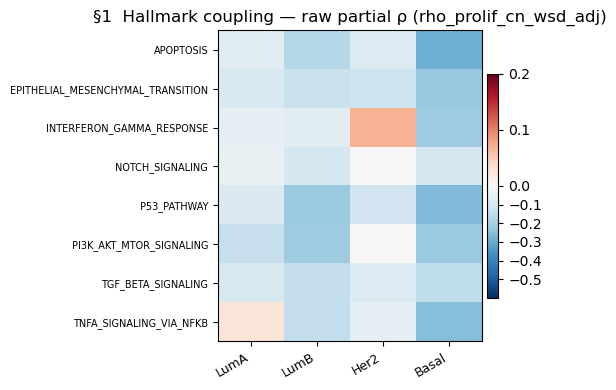

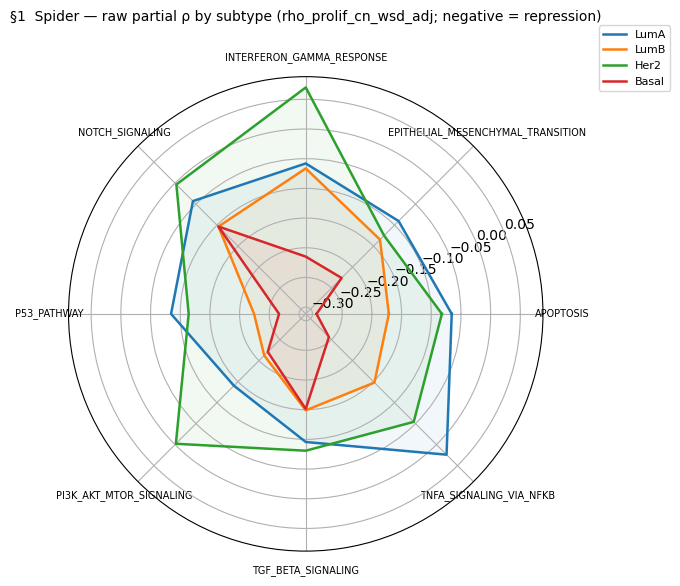

In [14]:
SCOPE = "Basal"  # LumA | LumB | Her2 | Basal (no cohort)
KEY_HALLMARK_ONLY = True
RHO_COL = "rho_prolif_cn_wsd_adj"  # partial ρ table column (raw ρ in plots)

hallmark_by_pam50 = load_tsv(AIM1 / "hallmark_coupling_by_pam50_prolif.tsv")

sub, label, col = filter_scope(hallmark_by_pam50, SCOPE)
view = maybe_key_hallmarks(sub, KEY_HALLMARK_ONLY).sort_values(RHO_COL)
print(f"Scope table: {label}  (column={col!r}, rows={len(view)})")
show(view)

# --- raw partial ρ only (no z-scoring) ---
mat_all = hallmark_subtype_matrix(hallmark_by_pam50, rho_col=RHO_COL, key_only=KEY_HALLMARK_ONLY)
print(f"Heatmap/spider matrix: {mat_all.shape[0]} programs x {mat_all.shape[1]} subtypes")

plot_matrix_heatmap(
    mat_all,
    f"§1  Hallmark coupling — raw partial ρ ({RHO_COL})",
    vmin=-0.6,
    vcenter=0,
    vmax=0.2,
)
plot_hallmark_subtype_spider(
    mat_all,
    title=f"§1  Spider — anti-correlation (−ρ) by subtype ({RHO_COL}; further out = stronger repression)",
)



## 2. Hallmark coupling — proliferation proxy ladder

**File:** `hallmark_coupling_prolif.tsv` · **Edit in code cell:** `SCOPE`, `KEY_HALLMARK_ONLY`

### Headline — PAM50 comparison (`survives_e2f_g2m`: ρ<0 & p<0.05, key programs)

| Scope | Key programs surviving | Median ρ (e2f_g2m) | What to notice |
|-------|------------------------|--------------------|----------------|
| cohort | 8/8 | −0.18 | Pooled signal is strong |
| **Basal** | **7/8** | **−0.24** | Strongest median; coupling *deepens* after prolif adjustment (suppressor confound) |
| LumB | 5/8 | −0.15 | Intermediate |
| LumA | 3/8 | −0.07 | Weak |
| Her2 | 0/8 | −0.08 | No key-program survival at p<0.05 |

**Basal-unique vs Her2:** Basal retains 7/8 key programs after proliferation adjustment; Her2 retains 0/8 — same pattern as §1 but without CN/wsd controls.

**Compare proxies in your scope:** if coupling survives `mki67` and `ortho_noE2F_MYC`, not just `e2f_g2m`, the proliferation objection is closed.

### Method
Same Y/X as §1; no CN or within-subtype z. Columns `rho_e2f_g2m`, `rho_mki67`, `rho_ortho_noE2F_MYC` (+ survives flags).


In [4]:
SCOPE = "Her2"  # cohort | LumA | LumB | Her2 | Basal
KEY_HALLMARK_ONLY = False

hallmark_coupling_prolif = load_tsv(AIM1 / "hallmark_coupling_prolif.tsv")

sub, label, col = filter_scope(hallmark_coupling_prolif, SCOPE)
view = maybe_key_hallmarks(sub, KEY_HALLMARK_ONLY).sort_values("rho_e2f_g2m")
print(f"Scope: {label}  (column={col!r}, rows={len(view)})")
show(view)


Scope: PAM50 HER2-enriched  (column='scope', rows=50)


,hallmark_set,scope,n,key_hallmark,rho_CPE_HRD,p_CPE_HRD,rho_e2f_g2m,p_e2f_g2m,survives_e2f_g2m,rho_mki67,p_mki67,survives_mki67,rho_ortho_noE2F_MYC,p_ortho_noE2F_MYC,survives_ortho_noE2F_MYC
51,HALLMARK_APICAL_SURFACE,Her2,92,False,-0.2161,0.041984,-0.1972,0.063946,False,-0.2120,0.046117,True,-0.1862,0.080689,False
50,HALLMARK_MYC_TARGETS_V2,Her2,92,False,-0.1694,0.112492,-0.1906,0.073641,False,-0.1428,0.181781,False,-0.2235,0.035219,True
54,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,Her2,92,True,-0.1449,0.175548,-0.1523,0.154217,False,-0.1353,0.206132,False,-0.1502,0.159932,False
64,HALLMARK_UV_RESPONSE_UP,Her2,92,False,-0.0466,0.664234,-0.1443,0.177298,False,-0.0691,0.519827,False,-0.0930,0.386015,False
52,HALLMARK_ESTROGEN_RESPONSE_EARLY,Her2,92,False,-0.1314,0.219807,-0.1429,0.181518,False,-0.1468,0.169872,False,-0.1685,0.114448,False
58,HALLMARK_DNA_REPAIR,Her2,92,False,-0.0583,0.587404,-0.1407,0.188552,False,-0.1043,0.330902,False,-0.1356,0.205269,False
62,HALLMARK_OXIDATIVE_PHOSPHORYLATION,Her2,92,False,0.0095,0.929848,-0.1363,0.202924,False,-0.0827,0.441184,False,-0.1012,0.345308,False
59,HALLMARK_MYC_TARGETS_V1,Her2,92,False,-0.0443,0.680432,-0.1337,0.211539,False,-0.0685,0.523751,False,-0.1277,0.232978,False
57,HALLMARK_P53_PATHWAY,Her2,92,True,-0.0727,0.498111,-0.1327,0.215140,False,-0.0837,0.435634,False,-0.1422,0.183841,False
56,HALLMARK_MYOGENESIS,Her2,92,False,-0.0796,0.458358,-0.1289,0.228549,False,-0.0793,0.459805,False,-0.1425,0.182730,False


shape: (50, 15)


,hallmark_set,scope,n,key_hallmark,rho_CPE_HRD,p_CPE_HRD,rho_e2f_g2m,p_e2f_g2m,survives_e2f_g2m,rho_mki67,p_mki67,survives_mki67,rho_ortho_noE2F_MYC,p_ortho_noE2F_MYC,survives_ortho_noE2F_MYC
51,HALLMARK_APICAL_SURFACE,Her2,92,False,-0.2161,0.041984,-0.1972,0.063946,False,-0.2120,0.046117,True,-0.1862,0.080689,False
50,HALLMARK_MYC_TARGETS_V2,Her2,92,False,-0.1694,0.112492,-0.1906,0.073641,False,-0.1428,0.181781,False,-0.2235,0.035219,True
54,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,Her2,92,True,-0.1449,0.175548,-0.1523,0.154217,False,-0.1353,0.206132,False,-0.1502,0.159932,False
64,HALLMARK_UV_RESPONSE_UP,Her2,92,False,-0.0466,0.664234,-0.1443,0.177298,False,-0.0691,0.519827,False,-0.0930,0.386015,False
52,HALLMARK_ESTROGEN_RESPONSE_EARLY,Her2,92,False,-0.1314,0.219807,-0.1429,0.181518,False,-0.1468,0.169872,False,-0.1685,0.114448,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,HALLMARK_GLYCOLYSIS,Her2,92,False,0.1106,0.302131,0.1600,0.134253,False,0.1475,0.167680,False,0.1401,0.190287,False
96,HALLMARK_G2M_CHECKPOINT,Her2,92,False,0.0968,0.366836,0.1656,0.120936,False,-0.0197,0.854383,False,0.1568,0.142146,False
98,HALLMARK_PROTEIN_SECRETION,Her2,92,False,0.1589,0.136832,0.1761,0.098790,False,0.1920,0.071388,False,0.1798,0.091775,False
97,HALLMARK_FATTY_ACID_METABOLISM,Her2,92,False,0.1982,0.062623,0.1908,0.073327,False,0.1980,0.062831,False,0.1703,0.110527,False


## 3. Hub routes — one miRNA arm → one target gene

**File:** `hub_route_partial_corr.tsv` · **Edit in code cell:** `SCOPE`

### Headline — gene routes surviving CPE+HRD+prolif+CN (`survives_e2f_g2m_CN`)

| Target | Basal | Her2 | cohort | What to notice |
|--------|-------|------|--------|----------------|
| PTEN | 3/3 arms | 3/3 | 3/3 | Robust across subtypes (miR-17/20a/106b) |
| CDKN1A (p21) | 3/3 | 1/3 | 3/3 | Basal/cohort strong; Her2 weaker |
| TGFBR2, VIM | 2/2, 1/2 | 2/2, 1/2 | partial | Basal-enriched but not Basal-exclusive |
| **BCL2L11 (BIM)** | **0/3** | **0/3** | 3/3 | **Fails in Basal/Her2**; only cohort pooled signal |
| **IRF1** | **0/2** | **0/2** | 1/2 | Immune route does not survive in Basal |

**Basal-unique failure:** BIM and IRF1 — do not claim these nodes from Basal hub routes; apoptosis *program* (§1) can still couple.

### Method
Y = target log2(TPM+1); X = single miRNA arm RPM; partial Spearman ladder incl. target ASCAT3 CN.


Scope table: PAM50 Basal  (column='scope', rows=14)


,target,miRNA,n,rho_e2f_g2m,p_e2f_g2m,survives_e2f_g2m,rho_e2f_g2m_CN,p_e2f_g2m_CN,survives_e2f_g2m_CN
0,BCL2L11,hsa-miR-106b-5p,188,-0.1200,1.135741e-01,False,-0.1279,9.544571e-02,False
1,BCL2L11,hsa-miR-17-5p,188,-0.0896,2.383914e-01,False,-0.0890,2.470529e-01,False
2,BCL2L11,hsa-miR-20a-5p,188,-0.1382,6.807693e-02,False,-0.1370,7.401953e-02,False
15,CDKN1A,hsa-miR-106b-5p,188,-0.3807,2.024689e-07,True,-0.3683,7.177933e-07,True
16,CDKN1A,hsa-miR-17-5p,188,-0.2972,6.495359e-05,True,-0.3096,3.784065e-05,True
17,CDKN1A,hsa-miR-20a-5p,188,-0.1676,2.665724e-02,True,-0.1749,2.217182e-02,True
30,IRF1,hsa-miR-106b-5p,188,-0.0380,6.178957e-01,False,0.0236,7.591520e-01,False
31,IRF1,hsa-miR-23a-3p,188,0.0601,4.296044e-01,False,0.0986,1.995974e-01,False
40,PTEN,hsa-miR-106b-5p,188,-0.3869,1.228659e-07,True,-0.3652,9.041262e-07,True
41,PTEN,hsa-miR-17-5p,188,-0.2004,7.837436e-03,True,-0.2370,1.804718e-03,True


shape: (14, 9)


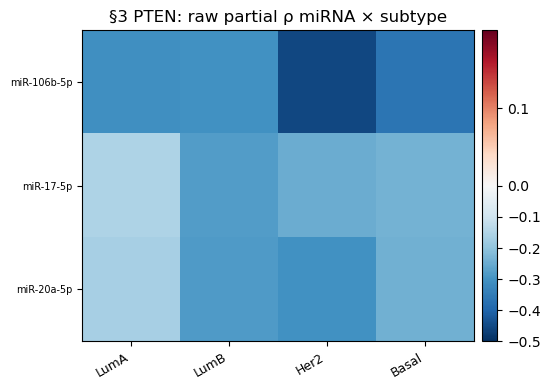

Antagonism: cohort z(predictor)>1 & z(target)<-1 (z_ref=cohort)


,target,aggregator,aggregator_type,subtype,n,pct_antagonism,z_reference,mirna_z_min,target_z_max,miRNA
0,PTEN,hsa-miR-106b-5p,arm,LumA,503,0.8,cohort,1,-1,hsa-miR-106b-5p
1,PTEN,hsa-miR-106b-5p,arm,LumB,259,1.5,cohort,1,-1,hsa-miR-106b-5p
2,PTEN,hsa-miR-106b-5p,arm,Her2,92,4.3,cohort,1,-1,hsa-miR-106b-5p
3,PTEN,hsa-miR-106b-5p,arm,Basal,188,26.6,cohort,1,-1,hsa-miR-106b-5p
4,PTEN,hsa-miR-17-5p,arm,LumA,503,0.2,cohort,1,-1,hsa-miR-17-5p
5,PTEN,hsa-miR-17-5p,arm,LumB,259,1.2,cohort,1,-1,hsa-miR-17-5p
6,PTEN,hsa-miR-17-5p,arm,Her2,92,0.0,cohort,1,-1,hsa-miR-17-5p
7,PTEN,hsa-miR-17-5p,arm,Basal,188,26.6,cohort,1,-1,hsa-miR-17-5p
8,PTEN,hsa-miR-20a-5p,arm,LumA,503,0.4,cohort,1,-1,hsa-miR-20a-5p
9,PTEN,hsa-miR-20a-5p,arm,LumB,259,1.9,cohort,1,-1,hsa-miR-20a-5p


shape: (12, 10)


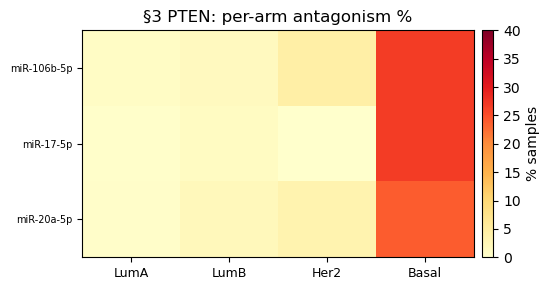

,target,aggregator,aggregator_type,subtype,n,pct_antagonism,z_reference,mirna_z_min,target_z_max
0,PTEN,family:miR-17~92,family,LumA,503,0.2,cohort,1,-1
1,PTEN,family:miR-17~92,family,LumB,259,2.3,cohort,1,-1
2,PTEN,family:miR-17~92,family,Her2,92,1.1,cohort,1,-1
3,PTEN,family:miR-17~92,family,Basal,188,27.7,cohort,1,-1
4,PTEN,combined_HE_pressure,combined_pressure,LumA,503,0.4,cohort,1,-1
5,PTEN,combined_HE_pressure,combined_pressure,LumB,259,0.8,cohort,1,-1
6,PTEN,combined_HE_pressure,combined_pressure,Her2,92,1.1,cohort,1,-1
7,PTEN,combined_HE_pressure,combined_pressure,Basal,188,22.3,cohort,1,-1


shape: (8, 9)


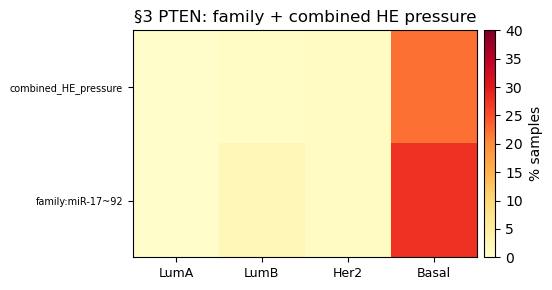

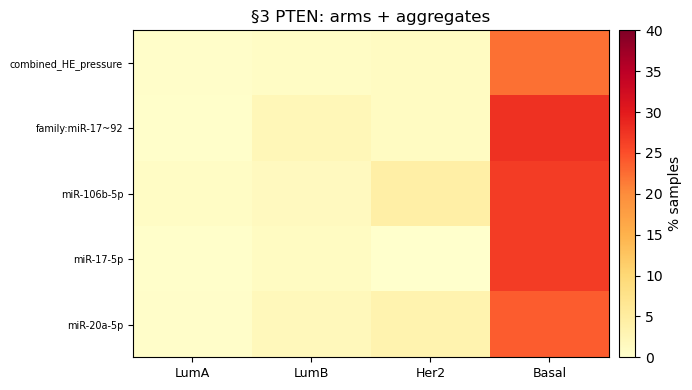

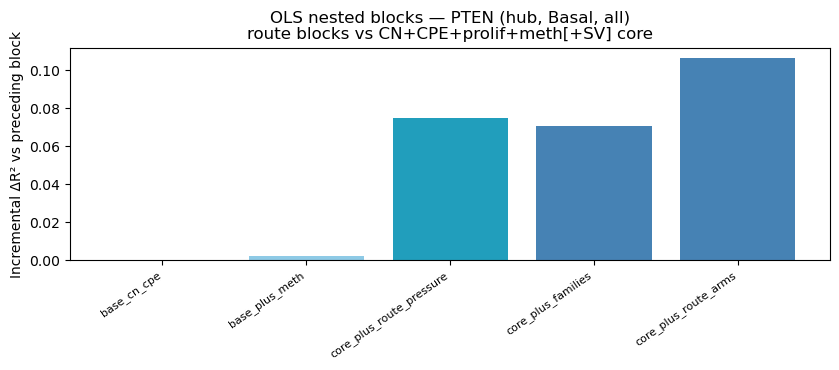

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,delta_r2_vs_core,n,n_meth_assayed,n_sv_assayed
0,base_cn_cpe,0.2927,0.0000,0.0000,0.0000,188,134,0
1,base_plus_meth,0.2951,0.0023,0.0000,0.0000,188,134,0
2,core_plus_route_pressure,0.3697,0.0769,0.0746,0.0746,188,134,0
3,core_plus_families,0.3657,0.0730,0.0706,0.0706,188,134,0
4,core_plus_route_arms,0.4015,0.1088,0.1064,0.1064,188,134,0


shape: (5, 8)


,gene,route_set,scope,fit_set,model,term,beta,n
134,PTEN,hub,Basal,all,core_plus_route_arms,arm:hsa-miR-17-5p,-0.00255,188
135,PTEN,hub,Basal,all,core_plus_route_arms,arm:hsa-miR-20a-5p,-0.01677,188
136,PTEN,hub,Basal,all,core_plus_route_arms,arm:hsa-miR-106b-5p,-0.07212,188


shape: (3, 8)


In [7]:
SCOPE = "Basal"  # cohort | LumA | LumB | Her2 | Basal
HUB_GENE = "PTEN"  # PTEN | CDKN1A | TGFBR2 | VIM | IRF1 | BCL2L11 | FOXO1 | SDC4
RHO_COL = "rho_e2f_g2m_CN"
HE_ONLY = False
TOP_N_MIRNAS = 20
MIRNA_Z_MIN = 1
TARGET_Z_MAX = -1
WITHIN_SUBTYPE_Z = False

hub_routes = load_tsv(AIM1 / "hub_route_partial_corr.tsv")

sub, label, col = filter_scope(hub_routes, SCOPE)
view = sub.loc[sub["target"].isin(HUB_GENES)].sort_values(["target", "miRNA"])

cols = [
    "target", "miRNA", "n", "rho_e2f_g2m", "p_e2f_g2m", "survives_e2f_g2m",
    "rho_e2f_g2m_CN", "p_e2f_g2m_CN", "survives_e2f_g2m_CN",
]
print(f"Scope table: {label}  (column={col!r}, rows={len(view)})")
show(view[cols])

mat_gene = hub_route_subtype_matrix(
    hub_routes,
    HUB_GENE,
    rho_col=RHO_COL,
    he_only=HE_ONLY,
    top_n=TOP_N_MIRNAS,
)
if mat_gene.empty:
    print(f"No routes for {HUB_GENE!r} (HE_ONLY={HE_ONLY})")
else:
    plot_matrix_heatmap(
        mat_gene,
        f"§3 {HUB_GENE}: raw partial ρ miRNA × subtype",
        vmin=-0.5,
        vcenter=0,
        vmax=0.2,
        row_labels=[m.replace("hsa-", "") for m in mat_gene.index],
    )

    ant_arms = antagonism_pct_table(
        HUB_GENE,
        mat_gene.index.tolist(),
        mirna_z_min=MIRNA_Z_MIN,
        target_z_max=TARGET_Z_MAX,
        within_subtype_z=WITHIN_SUBTYPE_Z,
    )
    ant_agg = antagonism_aggregated_pct_table(
        HUB_GENE,
        mat_gene.index.tolist(),
        pressure_path=AIM1 / "mirtar_hub_gene_pressure_per_sample.tsv.gz",
        mirna_z_min=MIRNA_Z_MIN,
        target_z_max=TARGET_Z_MAX,
        within_subtype_z=WITHIN_SUBTYPE_Z,
    )
    if not ant_arms.empty or not ant_agg.empty:
        print(
            f"Antagonism: cohort z(predictor)>{MIRNA_Z_MIN} & z(target)<{TARGET_Z_MAX} "
            f"(z_ref={'within_subtype' if WITHIN_SUBTYPE_Z else 'cohort'})"
        )
        if not ant_arms.empty:
            show(ant_arms)
            plot_antagonism_heatmap(ant_arms, f"§3 {HUB_GENE}: per-arm antagonism %")
        if not ant_agg.empty:
            show(ant_agg)
            plot_antagonism_heatmap(ant_agg, f"§3 {HUB_GENE}: family + combined HE pressure")
        ant_all = pd.concat([ant_arms, ant_agg], ignore_index=True)
        plot_antagonism_heatmap(
            ant_all,
            f"§3 {HUB_GENE}: arms + aggregates",
            figsize=(7, max(4, 0.3 * ant_all['aggregator'].nunique() + 1)),
        )

# --- OLS variance explainability (sample × gene; meth + CN + miRNA block) ---
exp_path = explainability_dir(SCOPE) / "incremental_r2_hub_genes.tsv"
coef_path = explainability_dir(SCOPE) / "mirna_term_coefficients.tsv"
if not exp_path.exists():
    print(
        "Run: .venv/bin/python3 -m mirna_hallmark.gene_expression_explainability --scope all"
    )
else:
    exp_r2 = load_tsv(exp_path)
    ols_rs = hub_route_set(HUB_GENE, "hub")
    plot_incremental_r2(HUB_GENE, exp_r2, scope_label=SCOPE, route_set=ols_rs)
    if coef_path.exists():
        coef = load_tsv(coef_path)
        show(
            coef.loc[
                coef["gene"].eq(HUB_GENE)
                & coef["route_set"].eq(ols_rs)
                & coef["model"].eq("core_plus_route_arms")
                & coef["fit_set"].eq("all")
            ]
        )




## 3b. Sample × gene OLS explainability

Nested OLS on `log2(TPM+1)` with **CN + CPE + proliferation + cis meth (promoter or gene-body) + SV**, then route miRNA blocks.

IRF1 route sets: **`curated`** (miR-23a/106b), **`targetscan_alt`** (miR-130b/301), **`curated_plus_targetscan`** (union of both).

```bash
.venv/bin/python3 -m mirna_hallmark.gene_expression_explainability --scope all
```


IRF1 route sets — ΔR²(arms|core) by subtype


subtype,Basal,Her2,LumA,LumB
route_set,,,,
curated,0.006,0.025,0.021,0.043
curated_plus_targetscan,0.101,0.038,0.038,0.055
targetscan_alt,0.086,0.027,0.024,0.027


shape: (3, 4)
/tmp/ipykernel_1023568/2616887385.py:620: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  sub = sub.set_index("model").reindex([m for m in order if m in sub.index]).reset_index()


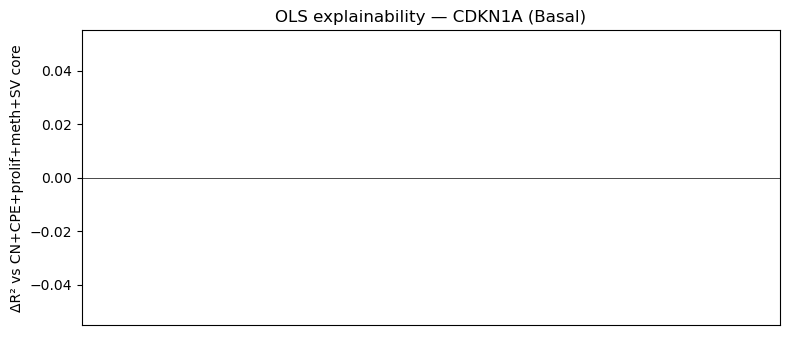

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,n,n_meth_assayed


shape: (0, 6)


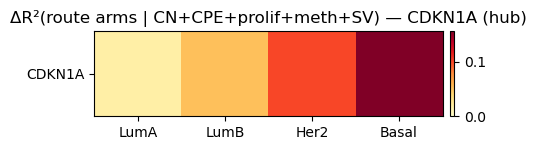

/tmp/ipykernel_1023568/2616887385.py:620: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  sub = sub.set_index("model").reindex([m for m in order if m in sub.index]).reset_index()


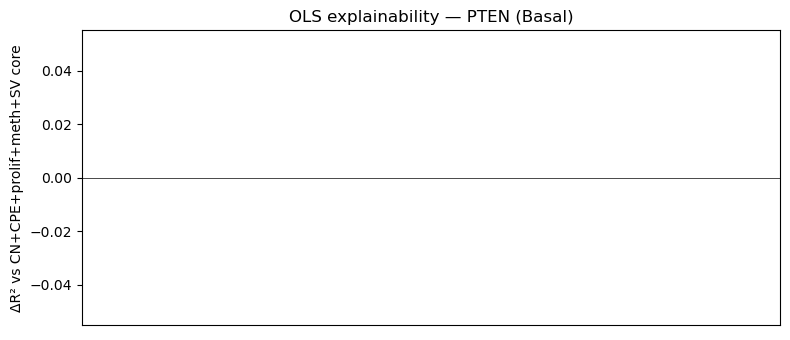

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,n,n_meth_assayed


shape: (0, 6)


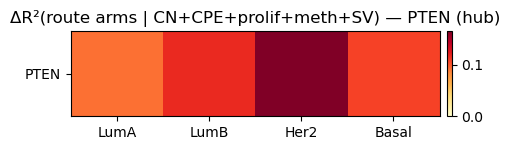

/tmp/ipykernel_1023568/2616887385.py:620: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  sub = sub.set_index("model").reindex([m for m in order if m in sub.index]).reset_index()


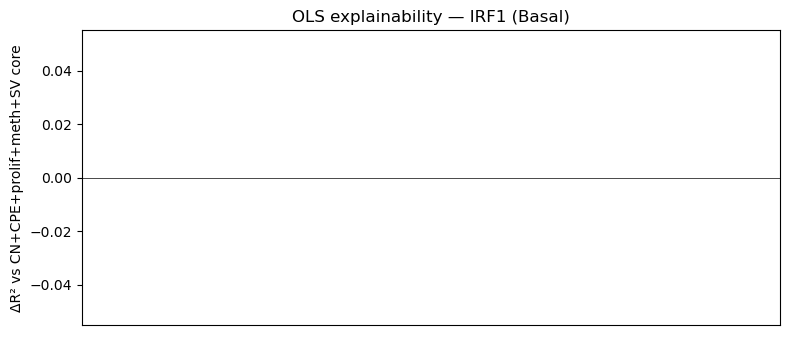

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,n,n_meth_assayed


shape: (0, 6)


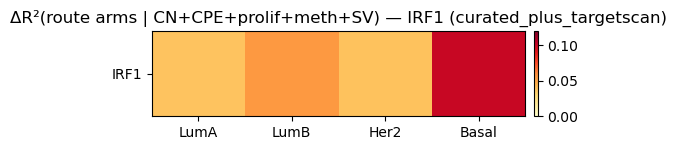

/tmp/ipykernel_1023568/2616887385.py:620: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  sub = sub.set_index("model").reindex([m for m in order if m in sub.index]).reset_index()


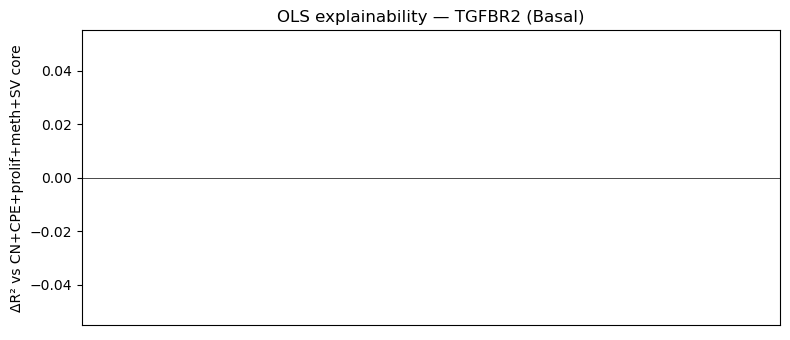

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,n,n_meth_assayed


shape: (0, 6)


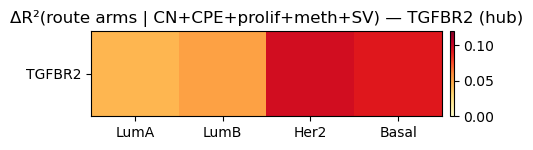

/tmp/ipykernel_1023568/2616887385.py:620: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  sub = sub.set_index("model").reindex([m for m in order if m in sub.index]).reset_index()


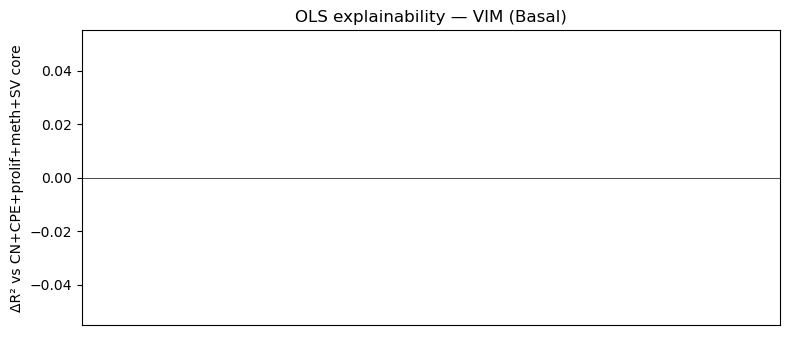

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,n,n_meth_assayed


shape: (0, 6)


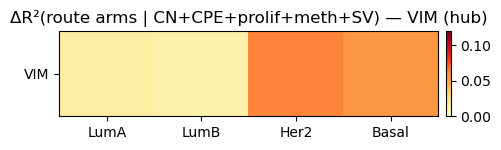

,route_set,r2,delta_r2_vs_core,n
69,curated_plus_targetscan,0.5922,0.1006,188
55,targetscan_alt,0.5773,0.0858,188
41,curated,0.4973,0.0058,188


/tmp/ipykernel_1023568/2616887385.py:620: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  sub = sub.set_index("model").reindex([m for m in order if m in sub.index]).reset_index()
shape: (3, 4)


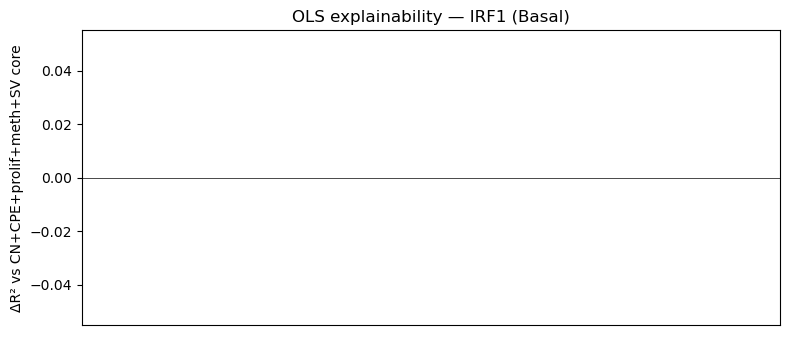

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,n,n_meth_assayed


shape: (0, 6)
/tmp/ipykernel_1023568/2616887385.py:620: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  sub = sub.set_index("model").reindex([m for m in order if m in sub.index]).reset_index()


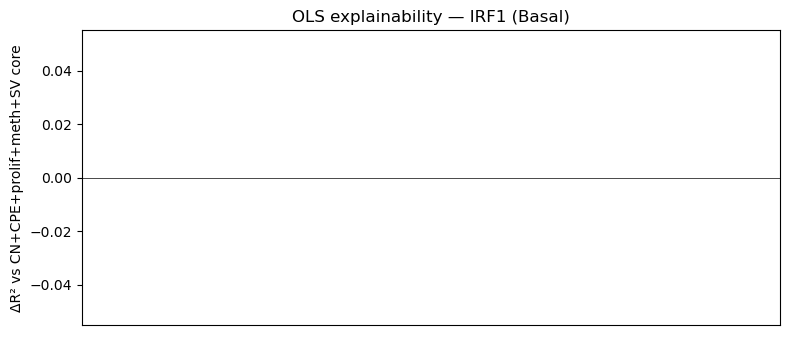

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,n,n_meth_assayed


shape: (0, 6)
/tmp/ipykernel_1023568/2616887385.py:620: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  sub = sub.set_index("model").reindex([m for m in order if m in sub.index]).reset_index()


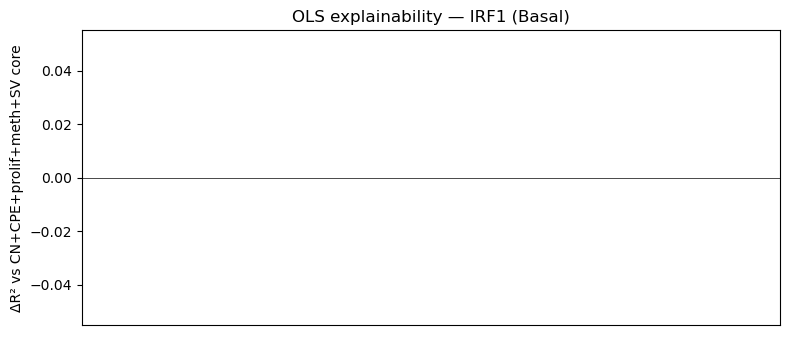

,model,r2,delta_r2_vs_base,delta_r2_vs_meth,n,n_meth_assayed


shape: (0, 6)


In [6]:
EXPLAIN_SCOPE = "Basal"
COMPARE_GENES = ["CDKN1A", "PTEN", "IRF1", "TGFBR2", "VIM"]
IRF1_ROUTE = "curated_plus_targetscan"  # curated | targetscan_alt | curated_plus_targetscan
IRF1_ROUTES_COMPARE = ["curated", "targetscan_alt", "curated_plus_targetscan"]

summary_path = EXPLAIN_DIR / "incremental_r2_by_subtype_summary.tsv"
r2_all = load_tsv(explainability_dir(EXPLAIN_SCOPE) / "incremental_r2_hub_genes.tsv")
if summary_path.exists():
    subtype_summary = load_tsv(summary_path)
    irf_cmp = subtype_summary.loc[
        subtype_summary["gene"].eq("IRF1")
        & subtype_summary["route_set"].isin(IRF1_ROUTES_COMPARE)
    ]
    print("IRF1 route sets — ΔR²(arms|core) by subtype")
    show(irf_cmp.pivot(index="route_set", columns="subtype", values="delta_r2_arms_vs_core").round(3))
else:
    subtype_summary = pd.DataFrame()

for g in COMPARE_GENES:
    rs = IRF1_ROUTE if g == "IRF1" else "hub"
    plot_incremental_r2(g, r2_all, scope_label=EXPLAIN_SCOPE, route_set=rs)
    if not subtype_summary.empty:
        plot_subtype_ols_heatmap(subtype_summary, g, route_set=rs)

# IRF1: compare all three route definitions within scope
irf_scope = r2_all.loc[
    r2_all["gene"].eq("IRF1")
    & r2_all["model"].eq("core_plus_route_arms")
    & r2_all["fit_set"].eq("all")
    & r2_all["route_set"].isin(IRF1_ROUTES_COMPARE)
]
show(
    irf_scope[["route_set", "r2", "delta_r2_vs_core", "n_meth_assayed", "n"]]
    .sort_values("delta_r2_vs_core", ascending=False)
)
for rs in IRF1_ROUTES_COMPARE:
    plot_incremental_r2("IRF1", r2_all, scope_label=EXPLAIN_SCOPE, route_set=rs)



## 4. Combined gene pressure → target RNA

**File:** `gene_pressure_route_partial_corr.tsv` · **Edit in code cell:** `SCOPE`

### Headline — aggregate pressure survival (`survives_e2f_g2m_CN`)

| Target | Basal | Her2 | LumB | cohort |
|--------|-------|------|------|--------|
| CDKN1A | ✓ | ✓ | ✗ | ✓ |
| TGFBR2, VIM | ✓ | VIM only | ✓ both | ✓ |
| PTEN | ✗ (borderline aggregate) | ✗ | ✓ | ✓ |
| BCL2L11, IRF1 | ✗ | ✗ | IRF1 ✓ | ✓ |

**Grant core (Basal):** CDKN1A, TGFBR2, VIM survive combined pressure + CN + prolif. PTEN survives via **individual arms** (§3) but aggregate pressure is borderline (p≈0.05). BIM/IRF1 fail.

**Her2 vs Basal:** Her2 keeps CDKN1A + VIM but loses TGFBR2 vs Basal; LumB shows broader survival including PTEN/IRF1 — subtype-specific node grammar, not one pan-cohort story.

### Method
Y = target RNA; X = sum of all high-evidence AGO-gated miRNA pressure on that gene.


Scope table: PAM50 Luminal B  (column='scope', rows=8)


,target,hub_miRNAs,n,rho_e2f_g2m,p_e2f_g2m,survives_e2f_g2m,rho_e2f_g2m_CN,p_e2f_g2m_CN,survives_e2f_g2m_CN,rho_mki67_CN,survives_mki67_CN
3,BCL2L11,"hsa-miR-106b-5p, hsa-miR-17-5p, hsa-miR-20a-5p",258,-0.1139,0.075142,False,-0.0911,0.161040,False,-0.0666,False
8,CDKN1A,"hsa-miR-106b-5p, hsa-miR-17-5p, hsa-miR-20a-5p",258,-0.0610,0.341807,False,-0.0834,0.199630,False,-0.0503,False
13,FOXO1,,258,-0.1298,0.042415,True,-0.1424,0.028005,True,-0.1402,True
18,IRF1,"hsa-miR-106b-5p, hsa-miR-23a-3p",258,-0.1966,0.001988,True,-0.2067,0.001344,True,-0.1860,True
23,PTEN,"hsa-miR-106b-5p, hsa-miR-17-5p, hsa-miR-20a-5p",258,-0.2007,0.001590,True,-0.1927,0.002830,True,-0.1600,True
28,SDC4,,258,-0.2235,0.000424,True,-0.2099,0.001124,True,-0.2046,True
33,TGFBR2,"hsa-miR-17-5p, hsa-miR-20a-5p",258,-0.2047,0.001277,True,-0.2109,0.001065,True,-0.1813,True
38,VIM,hsa-miR-17-5p,258,-0.1788,0.005009,True,-0.1817,0.004922,True,-0.1793,True


shape: (8, 11)


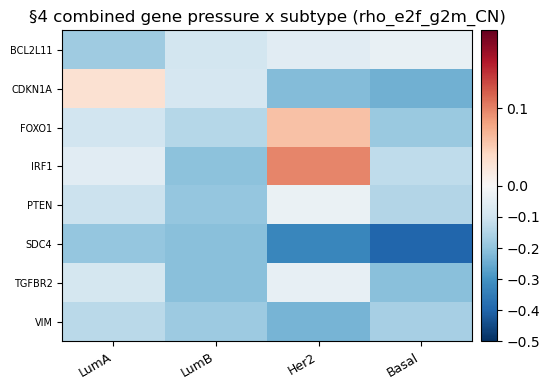

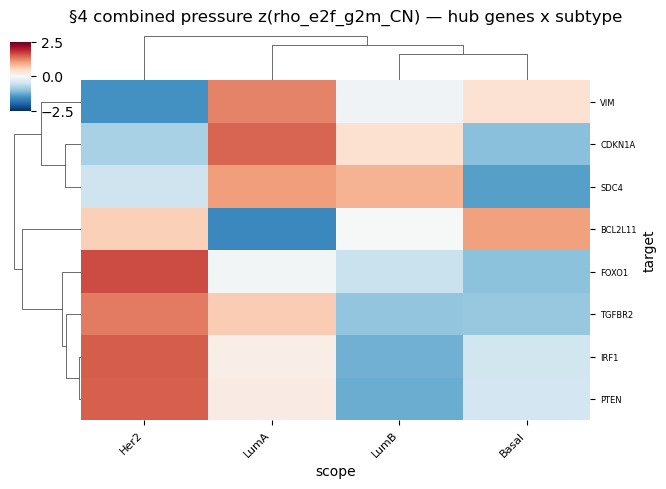

In [6]:
SCOPE = "LumB"  # cohort | LumA | LumB | Her2 | Basal
RHO_COL = "rho_e2f_g2m_CN"

hub_routes = load_tsv(AIM1 / "hub_route_partial_corr.tsv")
gene_pressure_routes = load_tsv(AIM1 / "gene_pressure_route_partial_corr.tsv")

sub, label, col = filter_scope(gene_pressure_routes, SCOPE)
view = attach_hub_mirnas(sub.sort_values("target"), hub_routes)

cols = [
    "target", "hub_miRNAs", "n", "rho_e2f_g2m", "p_e2f_g2m", "survives_e2f_g2m",
    "rho_e2f_g2m_CN", "p_e2f_g2m_CN", "survives_e2f_g2m_CN",
    "rho_mki67_CN", "survives_mki67_CN",
]
print(f"Scope table: {label}  (column={col!r}, rows={len(view)})")
show(view[cols])

# --- subtype x hub-gene aggregation heatmap (all PAM50) ---
mat_gp = gene_pressure_subtype_matrix(gene_pressure_routes, rho_col=RHO_COL, hub_only=True)
plot_matrix_heatmap(
    mat_gp,
    f"§4 combined gene pressure x subtype ({RHO_COL})",
    vmin=-0.5,
    vcenter=0,
    vmax=0.2,
)
z_gp = zscore_rows(mat_gp)
plot_coupling_clustermap(
    z_gp,
    f"§4 combined pressure z({RHO_COL}) — hub genes x subtype",
    vmin=-2.5,
    vcenter=0,
    vmax=2.5,
    figsize=(7, max(4, 0.45 * len(z_gp) + 1)),
)



## 5. Family-restricted Hallmark coupling

**File:** `family_coupling_by_pam50.tsv` · **Edit in code cell:** `SCOPE`, `FAMILY`

### Headline — miR-17∼92 cluster vs other families (`n_neg_sig` / 50, median ρ cn+wsd)

| Family | Basal | LumB | LumA | Her2 | What to notice |
|--------|-------|------|------|------|----------------|
| **miR-17∼92…** | **44/50, ρ̃−0.47** | 39/50 | 42/50 | 36/50 | **Only family with functional coupling**; Basal most negative median |
| miR-23∼27∼24 | 0/48 | 0/48 | 1/48 | 1/48 | High basal *load* (§7) but **uncoupled** |
| miR-221/222 | 0/40 | 1/40 | 1/40 | 0/40 | Uncoupled |

**Basal-unique (concentration, not exclusivity):** miR-17∼92 couples in all subtypes but is **most concentrated** in Basal (44 neg-sig, median ρ −0.47 vs Her2 −0.32). miR-23∼27∼24 is basal-high expression without coupling — key counterexample.

**Her2 note:** EMT couples strongly for miR-17∼92 in Her2 (ρ≈−0.50) — coupling is not Basal-exclusive per program.

### Method
Rebuild pressure using one family's edges only; partial Spearman vs Hallmark expression.


Scope table: PAM50 Basal  family='miR-17~92/106b~25/106a~363'  (rows=8)


,family,subtype,hallmark_set,key_hallmark,n,rho_prolif_adj,p_prolif_adj,rho_prolif_cn_wsd_adj,p_prolif_cn_wsd_adj,q_prolif_adj,q_prolif_cn_wsd_adj
156,miR-17~92/106b~25/106a~363,Basal,HALLMARK_APOPTOSIS,True,188,-0.5887,1.046007e-17,-0.5872,3.119996e-17,2.615017e-16,7.799989e-16
186,miR-17~92/106b~25/106a~363,Basal,HALLMARK_P53_PATHWAY,True,188,-0.5835,2.378456e-17,-0.5815,7.413346e-17,3.964093e-16,1.235558e-15
193,miR-17~92/106b~25/106a~363,Basal,HALLMARK_TGF_BETA_SIGNALING,True,188,-0.5219,1.293585e-13,-0.5305,8.438052e-14,5.879934e-13,5.273783e-13
163,miR-17~92/106b~25/106a~363,Basal,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,True,188,-0.5285,5.574382e-14,-0.5220,2.434997e-13,3.096879e-13,1.352776e-12
194,miR-17~92/106b~25/106a~363,Basal,HALLMARK_TNFA_SIGNALING_VIA_NFKB,True,188,-0.4754,2.981887e-11,-0.4915,8.717568e-12,5.734398e-11,2.294097e-11
184,miR-17~92/106b~25/106a~363,Basal,HALLMARK_NOTCH_SIGNALING,True,188,-0.4902,5.780093e-12,-0.4846,1.876428e-11,1.376213e-11,4.635233e-11
189,miR-17~92/106b~25/106a~363,Basal,HALLMARK_PI3K_AKT_MTOR_SIGNALING,True,188,-0.4840,1.150805e-11,-0.4717,7.402692e-11,2.501751e-11,1.480538e-10
176,miR-17~92/106b~25/106a~363,Basal,HALLMARK_INTERFERON_GAMMA_RESPONSE,True,188,-0.2861,1.241983e-04,-0.2931,9.993014e-05,1.552478e-04,1.249127e-04


shape: (8, 11)


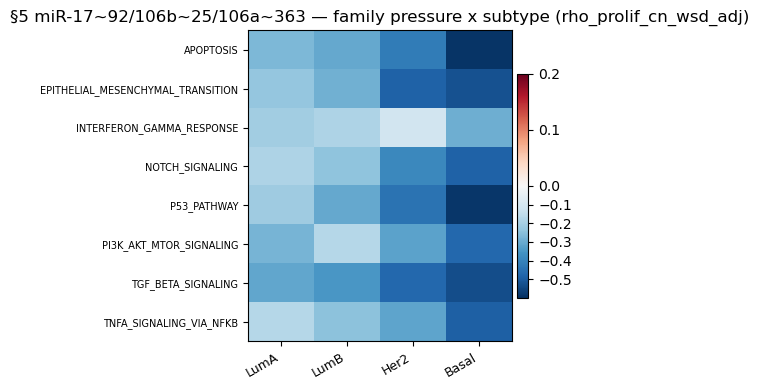

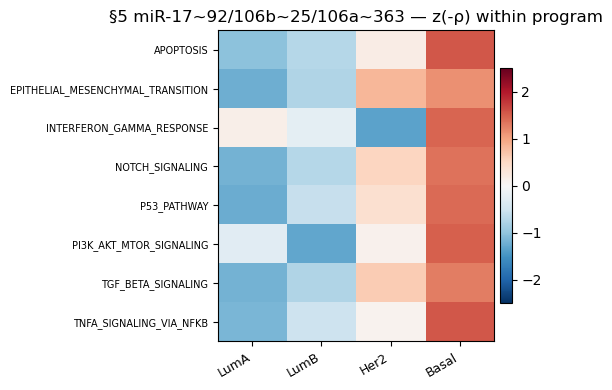

In [3]:
SCOPE = "Basal"  # LumA | LumB | Her2 | Basal
FAMILY = "miR-17~92/106b~25/106a~363"  # or miR-23~27~24 | miR-221/222
KEY_HALLMARK_ONLY = True
RHO_COL = "rho_prolif_cn_wsd_adj"

family_coupling = load_tsv(AIM1 / "family_coupling_by_pam50.tsv")

sub, label, col = filter_scope(family_coupling, SCOPE)
view = maybe_key_hallmarks(sub.loc[sub["family"] == FAMILY], KEY_HALLMARK_ONLY).sort_values(RHO_COL)
print(f"Scope table: {label}  family={FAMILY!r}  (rows={len(view)})")
show(view)

# --- family-restricted Hallmark x subtype heatmap (all PAM50) ---
mat_fam = family_coupling_subtype_matrix(
    family_coupling,
    FAMILY,
    rho_col=RHO_COL,
    key_only=KEY_HALLMARK_ONLY,
)
plot_matrix_heatmap(
    mat_fam,
    f"§5 {FAMILY} — family pressure x subtype ({RHO_COL})",
    vmin=-0.6,
    vcenter=0,
    vmax=0.2,
)
z_fam = zscore_anticorr_matrix(mat_fam)
plot_matrix_heatmap(
    z_fam,
    f"§5 {FAMILY} — z(-ρ) within program",
    vmin=-2.5,
    vcenter=0,
    vmax=2.5,
)



## 6. Family coupling summary (collapsed)

**File:** `family_specificity_summary.tsv` · **Edit in code cell:** `SCOPE`

### Headline
One row per family for your chosen subtype. **Notice:** miR-17∼92 `n_neg_sig` drops from Basal (44) → Her2 (36) but stays >> miR-23/221 families (~0–1). This is the formal "basal-maximal / concentrated" readout.

Compare across scopes by re-running with different `SCOPE` values.


In [8]:
SCOPE = "LumB"  # LumA | LumB | Her2 | Basal

family_summary = load_tsv(AIM1 / "family_specificity_summary.tsv")

sub, label, col = filter_scope(family_summary, SCOPE)
print(f"Scope: {label}  (rows={len(sub)})")
show(sub.sort_values(["family", col]))


Scope: PAM50 Luminal B  (rows=3)


,family,subtype,n_hallmarks,n_neg_sig,median_rho
1,miR-17~92/106b~25/106a~363,LumB,50,39,-0.2298
5,miR-221/222,LumB,40,1,0.0524
9,miR-23~27~24,LumB,48,0,0.0214


shape: (3, 5)


,family,subtype,n_hallmarks,n_neg_sig,median_rho
1,miR-17~92/106b~25/106a~363,LumB,50,39,-0.2298
5,miR-221/222,LumB,40,1,0.0524
9,miR-23~27~24,LumB,48,0,0.0214


## 7. Family basal load share (descriptive)

**File:** `family_load_share.tsv` · **No scope** — descriptive basal load only

### Headline
| Family | Share of basal positive load |
|--------|------------------------------|
| miR-17∼92 cluster | **22.1%** |
| miR-23∼27∼24 | 9.1% |
| miR-221/222 | 4.0% |

**What to notice:** Load ≠ coupling. miR-23∼27∼24 is 9% of load but uncoupled in §5 — separates expression enrichment from functional repression tracking.


In [4]:
family_load = load_tsv(AIM2 / "family_load_share.tsv")
show(family_load)

,family,n_arms_present,load_evidence,share_evidence_pct,load_targetscan,share_targetscan_pct,n_in_top10_by_load,n_in_top20_by_load
0,miR-17~92/106b~25/106a~363,18,643.40,22.1,62.78,28.2,4,7
1,miR-23~27~24,9,265.44,9.1,19.74,8.9,2,3
2,miR-221/222,4,117.11,4.0,8.09,3.6,1,2


shape: (3, 8)


,family,n_arms_present,load_evidence,share_evidence_pct,load_targetscan,share_targetscan_pct,n_in_top10_by_load,n_in_top20_by_load
0,miR-17~92/106b~25/106a~363,18,643.40,22.1,62.78,28.2,4,7
1,miR-23~27~24,9,265.44,9.1,19.74,8.9,2,3
2,miR-221/222,4,117.11,4.0,8.09,3.6,1,2


## 8. Proliferation sign structure (Basal only)

**File:** `prolif_sign_structure.tsv` · **Fixed scope: Basal** (no filter)

### Headline
Within Basal, proliferation correlates **positively** with both pressure and target expression for key programs → partialling proliferation **deepens** negative coupling (genuine suppressor confound, not artifact).

Gene level: PTEN shows strong prolif↔expression (+0.54 ortho proxy) while pressure coupling still survives — explains why adjustment strengthens PTEN routes.


In [5]:
sign_structure = load_tsv(AIM1 / "prolif_sign_structure.tsv")

view = sign_structure.sort_values(["level", "entity"])
show(view)

,level,entity,partner,scope,n,rho_prolif_pressure__e2f_g2m,rho_prolif_targetexpr__e2f_g2m,rho_prolif_pressure__mki67,rho_prolif_targetexpr__mki67,rho_prolif_pressure__ortho_noE2F_MYC,rho_prolif_targetexpr__ortho_noE2F_MYC
17,gene,BCL2L11,hsa-miR-17-5p,basal,188,0.4806,0.5172,0.3763,0.5669,0.2089,0.6063
18,gene,BCL2L11,hsa-miR-20a-5p,basal,188,0.4054,0.5172,0.2411,0.5669,0.1649,0.6063
19,gene,BCL2L11,hsa-miR-106b-5p,basal,188,0.2449,0.5172,0.1698,0.5669,-0.0492,0.6063
14,gene,CDKN1A,hsa-miR-17-5p,basal,188,0.4806,0.1457,0.3763,0.0762,0.2089,0.2706
15,gene,CDKN1A,hsa-miR-20a-5p,basal,188,0.4054,0.1457,0.2411,0.0762,0.1649,0.2706
16,gene,CDKN1A,hsa-miR-106b-5p,basal,188,0.2449,0.1457,0.1698,0.0762,-0.0492,0.2706
11,gene,FOXO1,hsa-miR-17-5p,basal,188,0.4806,0.0092,0.3763,0.0506,0.2089,0.3390
12,gene,FOXO1,hsa-miR-20a-5p,basal,188,0.4054,0.0092,0.2411,0.0506,0.1649,0.3390
13,gene,FOXO1,hsa-miR-106b-5p,basal,188,0.2449,0.0092,0.1698,0.0506,-0.0492,0.3390
20,gene,IRF1,hsa-miR-23a-3p,basal,188,0.1727,0.0879,0.1595,0.1163,0.1443,0.0831


shape: (28, 11)


,level,entity,partner,scope,n,rho_prolif_pressure__e2f_g2m,rho_prolif_targetexpr__e2f_g2m,rho_prolif_pressure__mki67,rho_prolif_targetexpr__mki67,rho_prolif_pressure__ortho_noE2F_MYC,rho_prolif_targetexpr__ortho_noE2F_MYC
17,gene,BCL2L11,hsa-miR-17-5p,basal,188,0.4806,0.5172,0.3763,0.5669,0.2089,0.6063
18,gene,BCL2L11,hsa-miR-20a-5p,basal,188,0.4054,0.5172,0.2411,0.5669,0.1649,0.6063
19,gene,BCL2L11,hsa-miR-106b-5p,basal,188,0.2449,0.5172,0.1698,0.5669,-0.0492,0.6063
14,gene,CDKN1A,hsa-miR-17-5p,basal,188,0.4806,0.1457,0.3763,0.0762,0.2089,0.2706
15,gene,CDKN1A,hsa-miR-20a-5p,basal,188,0.4054,0.1457,0.2411,0.0762,0.1649,0.2706
16,gene,CDKN1A,hsa-miR-106b-5p,basal,188,0.2449,0.1457,0.1698,0.0762,-0.0492,0.2706
11,gene,FOXO1,hsa-miR-17-5p,basal,188,0.4806,0.0092,0.3763,0.0506,0.2089,0.3390
12,gene,FOXO1,hsa-miR-20a-5p,basal,188,0.4054,0.0092,0.2411,0.0506,0.1649,0.3390
13,gene,FOXO1,hsa-miR-106b-5p,basal,188,0.2449,0.0092,0.1698,0.0506,-0.0492,0.3390
20,gene,IRF1,hsa-miR-23a-3p,basal,188,0.1727,0.0879,0.1595,0.1163,0.1443,0.0831


## 9. Hub ranking under three edge weightings

**File:** `mirna_basal_load_by_weighting.tsv` · **No scope** — basal load ranks

### Headline
**miR-17-5p rank #1** under evidence, binary (degree), and TargetScan weights — hub is not a miRTarBase study-count artifact.

Top load: miR-17-5p > miR-24-3p > miR-20a-5p by evidence; miR-17-5p stays top-3 under all weightings.


In [24]:
mirna_load = load_tsv(AIM2 / "mirna_basal_load_by_weighting.tsv")

view = mirna_load[
    mirna_load["rank_evidence"] <= 20
][["miRNA", "basal_mean_z", "load_evidence", "rank_evidence",
   "load_binary", "rank_binary", "load_targetscan", "rank_targetscan", "is_hub"]]

show(view)

,miRNA,basal_mean_z,load_evidence,rank_evidence,load_binary,rank_binary,load_targetscan,rank_targetscan,is_hub
0,hsa-miR-17-5p,1.285216,126.8192,1,64.2608,1,11.5001,1,True
1,hsa-miR-24-3p,0.994464,97.2992,2,51.7121,2,5.4586,10,False
2,hsa-miR-20a-5p,1.163682,87.3419,3,45.3836,3,7.9549,2,True
3,hsa-miR-27a-3p,0.770512,82.7339,4,44.6897,4,6.2866,8,False
4,hsa-miR-155-5p,0.791290,80.3690,5,43.5210,5,5.3871,11,False
5,hsa-miR-9-5p,1.049802,76.6746,6,41.9921,6,6.7271,6,False
6,hsa-miR-221-3p,0.792772,70.3181,7,38.0531,7,4.5973,15,False
7,hsa-miR-19a-3p,1.126492,60.7362,8,31.5418,11,7.8077,3,False
8,hsa-miR-106b-5p,1.054860,60.3294,9,31.6458,10,6.7880,5,True
9,hsa-miR-223-3p,0.712610,59.2439,10,33.4927,9,4.0170,21,False


shape: (20, 9)


,miRNA,basal_mean_z,load_evidence,rank_evidence,load_binary,rank_binary,load_targetscan,rank_targetscan,is_hub
0,hsa-miR-17-5p,1.285216,126.8192,1,64.2608,1,11.5001,1,True
1,hsa-miR-24-3p,0.994464,97.2992,2,51.7121,2,5.4586,10,False
2,hsa-miR-20a-5p,1.163682,87.3419,3,45.3836,3,7.9549,2,True
3,hsa-miR-27a-3p,0.770512,82.7339,4,44.6897,4,6.2866,8,False
4,hsa-miR-155-5p,0.791290,80.3690,5,43.5210,5,5.3871,11,False
5,hsa-miR-9-5p,1.049802,76.6746,6,41.9921,6,6.7271,6,False
6,hsa-miR-221-3p,0.792772,70.3181,7,38.0531,7,4.5973,15,False
7,hsa-miR-19a-3p,1.126492,60.7362,8,31.5418,11,7.8077,3,False
8,hsa-miR-106b-5p,1.054860,60.3294,9,31.6458,10,6.7880,5,True
9,hsa-miR-223-3p,0.712610,59.2439,10,33.4927,9,4.0170,21,False


### 9b. Hub-miRNA rank summary

**File:** `hub_rank_summary.tsv` · Hub arms only — compare ranks across weightings.


In [25]:
hub_rank = load_tsv(AIM2 / "hub_rank_summary.tsv")
show(hub_rank)

,miRNA,n_miRNAs_ranked,n_edges,ts_covered_edges,rank_evidence,rank_binary,rank_targetscan,load_evidence,load_binary,load_targetscan
0,hsa-miR-17-5p,515,50,35,1,1,1,126.8192,64.2608,11.5001
1,hsa-miR-20a-5p,515,39,29,3,3,2,87.3419,45.3836,7.9549
2,hsa-miR-106b-5p,515,30,24,9,10,5,60.3294,31.6458,6.7880
3,hsa-miR-23a-3p,515,32,23,15,15,13,43.9689,25.0437,4.9641


shape: (4, 10)


,miRNA,n_miRNAs_ranked,n_edges,ts_covered_edges,rank_evidence,rank_binary,rank_targetscan,load_evidence,load_binary,load_targetscan
0,hsa-miR-17-5p,515,50,35,1,1,1,126.8192,64.2608,11.5001
1,hsa-miR-20a-5p,515,39,29,3,3,2,87.3419,45.3836,7.9549
2,hsa-miR-106b-5p,515,30,24,9,10,5,60.3294,31.6458,6.7880
3,hsa-miR-23a-3p,515,32,23,15,15,13,43.9689,25.0437,4.9641


## 10. TargetScan top regulators per hub target

**File:** `per_target_top_regulators.tsv` · **No scope, not Basal-only, not coupling**

This table is **cohort-wide sequence prediction** (TargetScan weighted context++ scores). It does **not** use expression, PAM50 subtype, or partial Spearman. There is no "TargetScan coupling" in this pipeline — compare to §3–§4 for functional RNA tracking.

### Headline — TargetScan vs miRTarBase (discordance, not unexpected coupling)

| Target | TargetScan #1 | Has miRTarBase HE? | Arms that actually couple in Basal (§3) |
|--------|---------------|--------------------|----------------------------------------|
| PTEN | miR-19a/b-3p | Yes | **miR-17-5p / 20a / 106b** (not in TS top-6) |
| TGFBR2 | miR-520 family | **No** HE edge | **miR-17-5p / 20a** (not in TS top-6) |
| IRF1 | miR-301a/b-3p | **No** HE edge | miR-23a / 106b (weak; IRF1 route fails) |
| VIM | miR-124-3p | No | miR-17-5p (HE, couples) |
| CDKN1A | miR-519d-3p | Yes | miR-17/20a/106b (106b/20a in TS top-6) |

**What is interesting:** the **functionally coupled** oncomiR cluster (miR-17∼92 / 106b) is often **absent from TargetScan top-6**, while TargetScan favours other arms (miR-19 for PTEN, miR-520 for TGFBR2). That supports using **miRTarBase high-evidence edges + expression coupling** for mechanism, not raw TargetScan site rank alone.

**Aim 2 use of TargetScan:** re-weight basal *load* ranking (§9) — miR-17-5p still #1 — not per-gene coupling.


In [11]:
top_regulators = load_tsv(AIM2 / "per_target_top_regulators.tsv")

view = top_regulators[top_regulators["target"].isin(
    ["PTEN", "CDKN1A", "BCL2L11", "TGFBR2", "VIM", "IRF1"]
)].sort_values(["target", "ts_weight_abs_wcs"], ascending=[True, False])

show(view)

,target,miRNA,ts_weight_abs_wcs,is_hub,has_mirtarbase_he_edge
18,BCL2L11,hsa-miR-24-3p,0.741,False,True
19,BCL2L11,hsa-miR-124-3p.1,0.337,False,False
20,BCL2L11,hsa-miR-363-3p,0.321,False,True
21,BCL2L11,hsa-miR-367-3p,0.315,False,False
22,BCL2L11,hsa-miR-32-5p,0.312,False,True
23,BCL2L11,hsa-miR-1197,0.312,False,False
12,CDKN1A,hsa-miR-519d-3p,0.453,False,True
13,CDKN1A,hsa-miR-106b-5p,0.449,True,True
14,CDKN1A,hsa-miR-20a-5p,0.449,True,True
15,CDKN1A,hsa-let-7d-5p,0.447,False,False


shape: (36, 5)


,target,miRNA,ts_weight_abs_wcs,is_hub,has_mirtarbase_he_edge
18,BCL2L11,hsa-miR-24-3p,0.741,False,True
19,BCL2L11,hsa-miR-124-3p.1,0.337,False,False
20,BCL2L11,hsa-miR-363-3p,0.321,False,True
21,BCL2L11,hsa-miR-367-3p,0.315,False,False
22,BCL2L11,hsa-miR-32-5p,0.312,False,True
...,...,...,...,...,...
31,VIM,hsa-miR-138-5p,0.419,False,True
32,VIM,hsa-miR-325-3p,0.303,False,False
33,VIM,hsa-miR-30a-5p,0.292,False,True
34,VIM,hsa-miR-30b-5p,0.292,False,False


## 11. Raw Hallmark pressure matrix

**File:** `hallmark_interaction/hallmark_pressure_per_sample.tsv.gz` · Upstream input to coupling (not a correlation table).


In [6]:
pressure_path = INTERACTION / "hallmark_pressure_per_sample.tsv.gz"
if pressure_path.exists():
    hallmark_pressure = load_tsv(pressure_path, index_col=0)
    print(f"Hallmark pressure shape: {hallmark_pressure.shape}  (programs × samples)")
    display(hallmark_pressure.iloc[:5, :8])
    prog = "HALLMARK_APOPTOSIS"
    if prog in hallmark_pressure.index:
        display(hallmark_pressure.loc[prog].describe())
else:
    print(f"Not on disk: {pressure_path}")
    print("Generate with: .venv/bin/python3 -m mirna_hallmark.hallmark_interaction")
    hallmark_pressure = None

Hallmark pressure shape: (50, 1077)  (programs × samples)


,TCGA-3C-AAAU,TCGA-3C-AALI,TCGA-3C-AALJ,TCGA-3C-AALK,TCGA-4H-AAAK,TCGA-5L-AAT0,TCGA-5L-AAT1,TCGA-5T-A9QA
HALLMARK_ADIPOGENESIS,0.037681,-0.873261,-0.078587,-0.154798,-1.121861,-0.563885,-0.176395,0.268437
HALLMARK_ALLOGRAFT_REJECTION,0.132601,-1.737545,-0.640486,-0.807107,-2.589003,-2.011853,-0.773293,0.093311
HALLMARK_ANDROGEN_RESPONSE,1.003827,-2.624376,-1.281396,-1.416612,-3.032110,-2.540232,-1.287834,0.664280
HALLMARK_ANGIOGENESIS,0.654797,-3.087511,-1.411772,-0.920856,-3.596452,-1.578435,-0.559036,1.794845
HALLMARK_APICAL_JUNCTION,1.040473,-1.410962,-0.493949,-0.961875,-3.058471,-2.229002,-1.085766,1.120718


count    1077.000000
mean       -0.025678
std         3.131060
min       -12.988792
25%        -1.862763
50%         0.057377
75%         1.888864
max         9.869327
Name: HALLMARK_APOPTOSIS, dtype: float64

## 12. Headline subtype comparison (all PAM50)

Recomputed from §1 — always shows **all four subtypes**. Edit `HIGHLIGHT` in code cell to mark your focus subtype.

| Subtype | All neg-sig | Key neg-sig |
|---------|-------------|-------------|
| Basal | 42/50 | 8/8 |
| LumB | 17/50 | 4/8 |
| LumA | 18/50 | 4/8 |
| Her2 | 0/50 | 0/8 |


In [7]:
HIGHLIGHT = "Basal"  # which subtype row to flag (optional)

if "hallmark_by_pam50" not in globals():
    hallmark_by_pam50 = load_tsv(AIM1 / "hallmark_coupling_by_pam50_prolif.tsv")


def count_negsig(df, subtype, rho="rho_prolif_cn_wsd_adj", q="q_prolif_cn_wsd_adj", key_only=False):
    g = df[df["subtype"] == subtype]
    if key_only:
        g = g[g["key_hallmark"] == True]
    n = int(((g[rho] < 0) & (g[q] < 0.10)).sum())
    return n, len(g)

rows = []
for sub in PAM50_SUBTYPES:
    na, ta = count_negsig(hallmark_by_pam50, sub, key_only=False)
    nk, tk = count_negsig(hallmark_by_pam50, sub, key_only=True)
    rows.append({"subtype": sub, "all_neg_sig": f"{na}/{ta}", "key_neg_sig": f"{nk}/{tk}",
                 "highlight": sub == _normalize_scope(HIGHLIGHT)})

print("Neg-sig: rho_prolif_cn_wsd_adj<0 & q<0.10 within subtype")
display(pd.DataFrame(rows))


Neg-sig: rho_prolif_cn_wsd_adj<0 & q<0.10 within subtype


,subtype,all_neg_sig,key_neg_sig,highlight
0,LumA,5/50,1/8,False
1,LumB,15/50,5/8,False
2,Her2,0/50,0/8,False
3,Basal,24/50,7/8,True


## 13. Subtype comparison plots (choose resolution)

Three adequate resolutions for **PAM50 comparison** (all read precomputed tables):

| Panel | Resolution | Table | What it shows |
|-------|------------|-------|----------------|
| **A** | 8 key Hallmarks × 4 PAM50 | §1 `hallmark_coupling_by_pam50_prolif` | Program-level coupling (strictest ρ); **best for grant story** |
| **B** | 3 families × 4 PAM50 | §6 `family_specificity_summary` | Median ρ or neg-sig count; separates miR-17∼92 from load-only families |
| **C** | 8 hub targets × 5 scopes | §4 `gene_pressure_route_partial_corr` | Node-level aggregate pressure survival (binary) |

**Not adequate for subtype comparison:** §7–§10 (basal load or static TargetScan; no per-subtype coupling), §8 (Basal-only diagnostic).

Run the next cell; edit `RHO_COL`, `KEY_ONLY`, and `SCOPES` as needed. Requires `matplotlib` (in project venv).


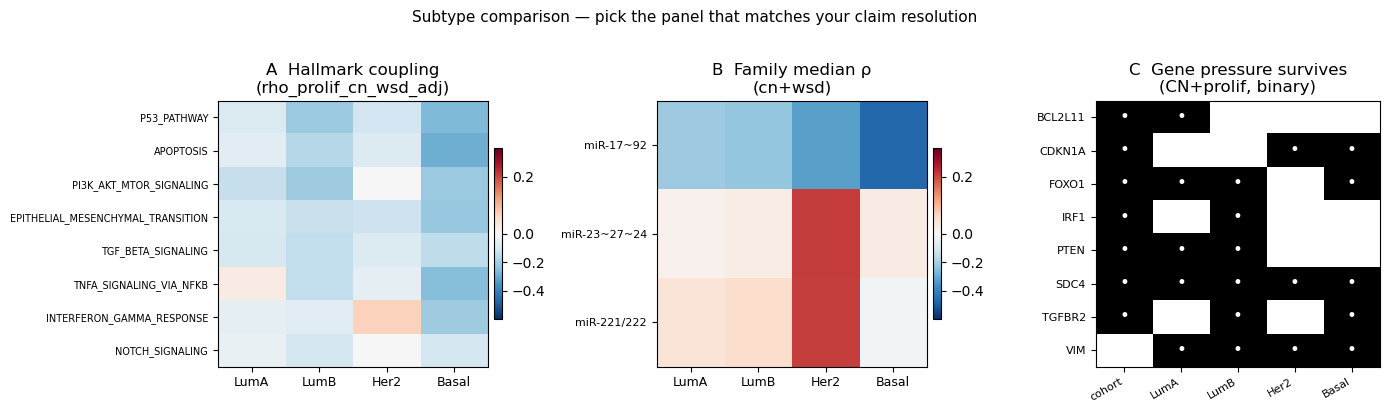

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- edit knobs ---
RHO_COL = "rho_prolif_cn_wsd_adj"  # §1 strictest; or rho_prolif_adj
KEY_ONLY = True                     # 8 key Hallmarks vs all 50
SCOPES = ["LumA", "LumB", "Her2", "Basal"]

by = load_tsv(AIM1 / "hallmark_coupling_by_pam50_prolif.tsv")
fs = load_tsv(AIM1 / "family_specificity_summary.tsv")
gp = load_tsv(AIM1 / "gene_pressure_route_partial_corr.tsv")

# --- Panel A: Hallmark x PAM50 ---
rows = by.loc[by.key_hallmark] if KEY_ONLY else by
rows = rows.drop_duplicates(["hallmark_set", "subtype"])
hallmarks = sorted(rows.hallmark_set.unique(), key=lambda h: rows.loc[rows.hallmark_set==h, RHO_COL].mean())
mat = rows.pivot(index="hallmark_set", columns="subtype", values=RHO_COL).reindex(columns=SCOPES)
mat = mat.loc[hallmarks]

fig, axes = plt.subplots(1, 3, figsize=(14, max(4, 0.28 * len(mat) + 1.5)))

# A
ax = axes[0]
v = mat.values.astype(float)
norm = plt.cm.colors.TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.3)
im = ax.imshow(v, aspect="auto", cmap="RdBu_r", norm=norm)
ax.set_xticks(range(len(SCOPES)))
ax.set_xticklabels(SCOPES, fontsize=9)
ax.set_yticks(range(len(mat)))
ax.set_yticklabels([h.replace("HALLMARK_", "") for h in mat.index], fontsize=7)
ax.set_title(f"A  Hallmark coupling\n({RHO_COL})")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

# B: family median rho
fam_order = [
    "miR-17~92/106b~25/106a~363",
    "miR-23~27~24",
    "miR-221/222",
]
fm = fs.pivot(index="family", columns="subtype", values="median_rho").reindex(fam_order).reindex(columns=SCOPES)
ax = axes[1]
im = ax.imshow(fm.values.astype(float), aspect="auto", cmap="RdBu_r", norm=norm)
ax.set_xticks(range(len(SCOPES)))
ax.set_xticklabels(SCOPES, fontsize=9)
ax.set_yticks(range(len(fm)))
ax.set_yticklabels(["miR-17~92", "miR-23~27~24", "miR-221/222"], fontsize=8)
ax.set_title("B  Family median ρ\n(cn+wsd)")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

# C: gene pressure survival
scopes_gp = ["cohort"] + SCOPES
targets = sorted(gp.target.unique())
surv = gp.pivot(index="target", columns="scope", values="survives_e2f_g2m_CN").reindex(index=targets, columns=scopes_gp)
surv = surv.fillna(False).astype(float)
ax = axes[2]
ax.imshow(surv.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_xticks(range(len(scopes_gp)))
ax.set_xticklabels(scopes_gp, fontsize=8, rotation=30, ha="right")
ax.set_yticks(range(len(targets)))
ax.set_yticklabels(targets, fontsize=8)
ax.set_title("C  Gene pressure survives\n(CN+prolif, binary)")
for i in range(surv.shape[0]):
    for j in range(surv.shape[1]):
        if surv.iloc[i, j]:
            ax.text(j, i, "•", ha="center", va="center", color="white", fontsize=12)

fig.suptitle("Subtype comparison — pick the panel that matches your claim resolution", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 14. TargetScan orphans — gene + program coupling & specificity

**Question:** Do TargetScan-predicted miRNA→target pairs **excluded from miRTarBase HE** show repression-consistent coupling in RNA?

**Orphan definition:** `ts_weight ≥ 0.25`, not a miRTarBase high-evidence edge. Program pressure = top-5 orphan arms/gene × AGO gate; Hallmark = mean over members. Coupling = partial Spearman (CPE+HRD+E2F/G2M; program also +CN+within-subtype z).

**Regenerate:** `.venv/bin/python3 -m mirna_hallmark.targetscan_orphan_coupling` (also runs at end of `robustness_checks`).

### Headline — program level (neg-sig: ρ<0 & q<0.10)

| Subtype | miRTar HE (§1) | Orphan TS-only (§14) |
|---------|----------------|----------------------|
| Basal | 42/50 (key 8/8) | 42/50 (key 8/8) |
| LumB | 17/50 (key 4/8) | 26/50 (key 6/8) |
| LumA | 18/50 (key 4/8) | 18/50 (key 5/8) |
| Her2 | 0/50 | 0/50 |

Orphan pressure inflates **breadth** of neg-sig Hallmarks (especially LumA/LumB) but does **not** add Basal-specific key programs — all 8 Basal key hits overlap miRTar HE under the adopted spine (none orphan-only). **Specificity is weaker than miRTar HE** at program level.

### Headline — aggregated hub genes (Basal, CN-surviving orphan arms)

| Hub | n arms | n neg-sig | n survives CN | Best arm (ρ) |
|-----|-------:|----------:|--------------:|--------------|
| CDKN1A | 14 | 8 | 8 | let-7g (−0.32) |
| PTEN | 5 | 3 | 3 | miR-188 (−0.28) |
| TGFBR2 | 14 | 3 | 3 | miR-520d (−0.41) |
| VIM | 7 | 1 | 1 | miR-30e (−0.22) |

**Clustering:** Basal orphan signal **clusters by seed family** on shared hubs — **miR-301/130/454/499** → CDKN1A (mostly zero miRTar studies); **miR-148** → PTEN; **miR-520d** → TGFBR2. Not a diffuse TS noise floor.

**Scope note:** Cells below use per-cell `SCOPE` for **within-scope coupling**. Cross-scope flags (`basal_concentrated`, `survives_Basal_CN`) live in `orphan_gene_specificity_summary.tsv` and are shown only when `SHOW_CROSS_SCOPE=True`.

In [9]:
# Program-level specificity: miRTar HE (§1) vs orphan TS-only pressure
orphan_hm_spec = load_tsv(ORPHAN / "orphan_hallmark_specificity_summary.tsv")
if "hallmark_by_pam50" not in globals():
    hallmark_by_pam50 = load_tsv(AIM1 / "hallmark_coupling_by_pam50_prolif.tsv")

rows = []
for sub in PAM50_SUBTYPES:
    na, ta = count_negsig(hallmark_by_pam50, sub, key_only=False)
    nk, tk = count_negsig(hallmark_by_pam50, sub, key_only=True)
    o = orphan_hm_spec.loc[orphan_hm_spec.subtype == sub].iloc[0]
    rows.append({
        "subtype": sub,
        "mirtar_all": f"{na}/{ta}",
        "mirtar_key": f"{nk}/{tk}",
        "orphan_all": f"{int(o.n_neg_sig)}/{int(o.n_hallmarks)}",
        "orphan_key": f"{int(o.n_key_neg_sig)}/8",
        "orphan_median_rho": o.median_rho,
        "basal_concentrated": bool(o.get("basal_concentrated_vs_others", False)),
    })
display(pd.DataFrame(rows))

cmp = load_tsv(ORPHAN / "orphan_vs_mirtar_coupling_comparison.tsv")
key_cmp = cmp.loc[cmp.key_hallmark_orphan.fillna(False) & cmp.subtype.eq("Basal")]
print("Basal key Hallmarks: orphan vs miRTar neg-sig overlap")
display(key_cmp[[
    "hallmark_set", "orphan_neg_sig", "mirtar_neg_sig",
    "rho_prolif_cn_wsd_adj_orphan", "rho_prolif_cn_wsd_adj_mirtar",
]])


,subtype,mirtar_all,mirtar_key,orphan_all,orphan_key,orphan_median_rho,basal_concentrated
0,LumA,5/50,1/8,21/50,6/8,-0.0733,False
1,LumB,15/50,5/8,27/50,8/8,-0.1295,False
2,Her2,0/50,0/8,0/50,0/8,-0.0365,False
3,Basal,24/50,7/8,38/50,7/8,-0.2023,True


Basal key Hallmarks: orphan vs miRTar neg-sig overlap


,hallmark_set,orphan_neg_sig,mirtar_neg_sig,rho_prolif_cn_wsd_adj_orphan,rho_prolif_cn_wsd_adj_mirtar
0,HALLMARK_APOPTOSIS,True,True,-0.4081,-0.2932
4,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,True,True,-0.2569,-0.2259
8,HALLMARK_INTERFERON_GAMMA_RESPONSE,True,True,-0.2739,-0.2149
12,HALLMARK_NOTCH_SIGNALING,False,False,-0.1220,-0.1032
16,HALLMARK_P53_PATHWAY,True,True,-0.2885,-0.2664
20,HALLMARK_PI3K_AKT_MTOR_SIGNALING,True,True,-0.2649,-0.2209
24,HALLMARK_TGF_BETA_SIGNALING,True,True,-0.2683,-0.1513
28,HALLMARK_TNFA_SIGNALING_VIA_NFKB,True,True,-0.3674,-0.2562


In [10]:
# Gene-level hub orphans — edit SCOPE per cell
SCOPE = "Basal"           # cohort | LumA | LumB | Her2 | Basal
MIN_TS = 0.25
SURVIVES_CN_ONLY = True   # filter to CN+prolif survival at SCOPE (from gene_detail)
ZERO_STUDIES_ONLY = False # True → no miRTarBase row at all
SHOW_CROSS_SCOPE = False  # True → second table with basal_concentrated / survives_Basal_CN flags

gene_spec = load_tsv(ORPHAN / "orphan_gene_specificity_summary.tsv")
gene_spec["basal_concentrated"] = gene_spec["basal_concentrated"].astype(bool)
gene_detail = load_tsv(ORPHAN / "orphan_gene_coupling_by_scope.tsv")
gene_agg = load_tsv(ORPHAN / "orphan_gene_aggregate_by_scope.tsv")

# --- Table 1: scope-resolved pairs (SCOPE drives this table) ---
sub_d = gene_detail.loc[gene_detail["scope"] == SCOPE].copy()
sub_d = sub_d.loc[sub_d["ts_weight"] >= MIN_TS]
if SURVIVES_CN_ONLY:
    sub_d = sub_d.loc[sub_d["survives_e2f_g2m_CN"]]
if ZERO_STUDIES_ONLY:
    sub_d = sub_d.loc[sub_d["n_studies"] == 0]

print(f"Orphan pairs at SCOPE={SCOPE} after filters: {len(sub_d)}")
cols = [
    "target", "miRNA", "ts_weight", "n_studies", "n",
    "rho_e2f_g2m_CN", "p_e2f_g2m_CN", "survives_e2f_g2m_CN",
]
show(sub_d.sort_values(["target", "rho_e2f_g2m_CN"])[cols])

# --- Hub aggregate at same SCOPE ---
agg = gene_agg.loc[gene_agg["scope"] == SCOPE].sort_values(
    ["n_survives_CN", "n_neg_sig"], ascending=[False, False]
)
print(f"\nAggregated per hub @ {SCOPE}:")
show(agg)

if SHOW_CROSS_SCOPE:
    print("\nCross-scope specificity flags (Basal-centric — not filtered by SCOPE above):")
    xs = gene_spec.loc[gene_spec["survives_Basal_CN"]].sort_values(
        ["basal_concentrated", "ts_weight"], ascending=[False, False]
    )
    show(xs[[
        "target", "miRNA", "ts_weight", "n_studies", "basal_concentrated",
        "neg_sig_Basal", "neg_sig_other_subtypes", "median_rho_Basal",
    ]])


Orphan pairs at SCOPE=Basal after filters: 15


,target,miRNA,ts_weight,n_studies,n,rho_e2f_g2m_CN,p_e2f_g2m_CN,survives_e2f_g2m_CN
69,CDKN1A,hsa-let-7g-5p,0.422,1,188,-0.3200,0.000020,True
89,CDKN1A,hsa-miR-499a-5p,0.261,0,188,-0.2820,0.042830,True
39,CDKN1A,hsa-let-7d-5p,0.447,1,188,-0.2219,0.003528,True
74,CDKN1A,hsa-miR-98-5p,0.422,1,188,-0.2115,0.005494,True
99,CDKN1A,hsa-miR-301a-3p,0.256,0,188,-0.2071,0.006570,True
84,CDKN1A,hsa-miR-454-3p,0.270,0,188,-0.1995,0.008893,True
79,CDKN1A,hsa-miR-130b-3p,0.278,0,188,-0.1639,0.032154,True
104,CDKN1A,hsa-miR-301b-3p,0.256,0,188,-0.1578,0.049116,True
209,PTEN,hsa-miR-188-5p,0.297,1,188,-0.2809,0.000282,True
199,PTEN,hsa-miR-107,0.343,1,188,-0.2141,0.004928,True


shape: (15, 8)

Aggregated per hub @ Basal:


,target,scope,n_orphan_arms,n_neg_sig,n_survives_CN,median_rho,best_arm,best_rho
0,CDKN1A,Basal,14,8,8,-0.1608,hsa-let-7g-5p,-0.3200
1,PTEN,Basal,5,3,3,-0.1757,hsa-miR-188-5p,-0.2809
2,TGFBR2,Basal,14,3,3,-0.0879,hsa-miR-520d-3p,-0.4112
3,VIM,Basal,7,1,1,-0.0719,hsa-miR-30e-5p,-0.2166
4,BCL2L11,Basal,7,0,0,0.0379,hsa-miR-92b-3p,-0.0465
5,FOXO1,Basal,3,0,0,-0.1167,hsa-miR-101-3p.1,-0.1333
6,IRF1,Basal,13,0,0,0.0016,hsa-miR-124-3p.1,-0.2128
7,SDC4,Basal,1,0,0,0.1375,hsa-miR-140-3p.2,0.1375


shape: (8, 8)


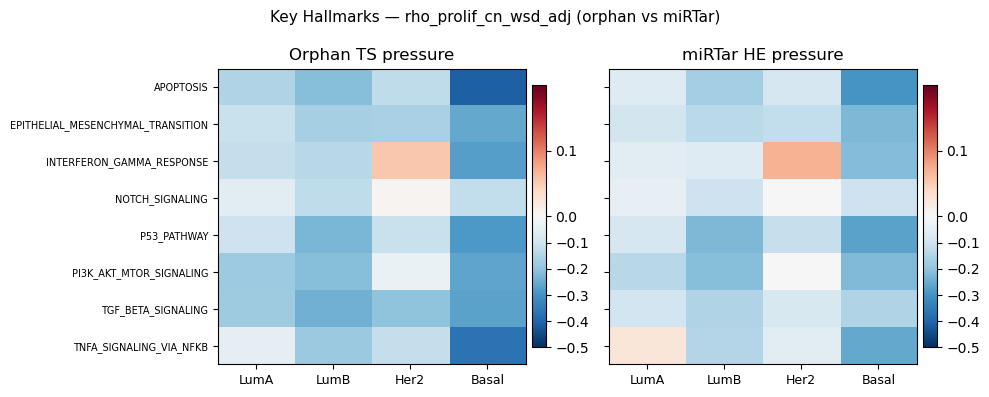

In [11]:
# Optional: heatmap — key Hallmarks × PAM50 (orphan vs miRTar side by side)
import matplotlib.pyplot as plt

RHO = "rho_prolif_cn_wsd_adj"
cmp = load_tsv(ORPHAN / "orphan_vs_mirtar_coupling_comparison.tsv")
keys = sorted(cmp.loc[cmp.key_hallmark_orphan.fillna(False), "hallmark_set"].unique())

def _mat(suffix: str) -> pd.DataFrame:
    col = f"{RHO}_{suffix}"
    return (
        cmp.loc[cmp.hallmark_set.isin(keys)]
        .pivot(index="hallmark_set", columns="subtype", values=col)
        .reindex(index=keys, columns=list(PAM50_SUBTYPES))
    )

m_o, m_m = _mat("orphan"), _mat("mirtar")
norm = plt.cm.colors.TwoSlopeNorm(vmin=-0.5, vcenter=0, vmax=0.2)
fig, axes = plt.subplots(1, 2, figsize=(10, max(4, 0.35 * len(keys) + 1)), sharey=True)
for ax, mat, title in zip(axes, (m_o, m_m), ("Orphan TS pressure", "miRTar HE pressure")):
    im = ax.imshow(mat.values.astype(float), aspect="auto", cmap="RdBu_r", norm=norm)
    ax.set_xticks(range(len(PAM50_SUBTYPES)))
    ax.set_xticklabels(PAM50_SUBTYPES, fontsize=9)
    ax.set_yticks(range(len(keys)))
    ax.set_yticklabels([h.replace("HALLMARK_", "") for h in keys], fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.suptitle(f"Key Hallmarks — {RHO} (orphan vs miRTar)", fontsize=11)
plt.tight_layout()
plt.show()


In [12]:
# Orphan miRNA seed-family clustering + subtype breadth
mir_cluster = load_tsv(ORPHAN / "orphan_mirna_cluster_summary.tsv")
arms = mir_cluster.loc[~mir_cluster["miRNA"].str.startswith("[family:")].copy()
fams = mir_cluster.loc[mir_cluster["miRNA"].str.startswith("[family:")].copy()

print("Basal neg-sig orphan arms (individual):")
show(arms.loc[arms["n_basal_neg_sig"] > 0].sort_values(
    ["seed_family", "n_basal_neg_sig"], ascending=[True, False]
))

print("\nSeed-family roll-up (clustered targets):")
show(fams.sort_values("n_basal_neg_sig", ascending=False))

mir_sub = load_tsv(ORPHAN / "orphan_mirna_coupling_by_subtype.tsv")
print("\nArms with deepest Basal vs luminal spread (median rho Basal - median rho LumA/LumB):")
mir_sub["lum_median"] = mir_sub[["LumA", "LumB"]].median(axis=1)
mir_sub["basal_minus_lum"] = mir_sub["Basal"] - mir_sub["lum_median"]
show(mir_sub.sort_values("basal_minus_lum").head(12)[
    ["miRNA", "seed_family", "Basal", "LumA", "LumB", "Her2", "basal_minus_lum"]
])

Basal neg-sig orphan arms (individual):


,miRNA,seed_family,n_hub_targets,n_basal_neg_sig,basal_neg_targets,median_rho_basal,basal_concentrated_any,zero_mirtar_studies,n_arms_in_family
0,hsa-let-7d-5p,let-7,1,1,CDKN1A,-0.2219,False,False,NaN
1,hsa-let-7g-5p,let-7,1,1,CDKN1A,-0.3200,False,False,NaN
7,hsa-miR-98-5p,let-7/98,1,1,CDKN1A,-0.2115,True,False,NaN
8,hsa-miR-107,miR-107,1,1,PTEN,-0.2141,False,False,NaN
9,hsa-miR-130b-3p,miR-130,1,1,CDKN1A,-0.1639,True,True,NaN
11,hsa-miR-148b-3p,miR-148,1,1,PTEN,-0.1757,True,True,NaN
12,hsa-miR-301a-3p,miR-301,3,2,CDKN1A;TGFBR2,-0.2071,True,True,NaN
13,hsa-miR-301b-3p,miR-301,3,1,CDKN1A,-0.1349,True,True,NaN
14,hsa-miR-454-3p,miR-454,4,2,CDKN1A;TGFBR2,-0.1638,False,True,NaN
15,hsa-miR-499a-5p,miR-499,1,1,CDKN1A,-0.2820,True,True,NaN


shape: (13, 9)

Seed-family roll-up (clustered targets):


,miRNA,seed_family,n_hub_targets,n_basal_neg_sig,basal_neg_targets,median_rho_basal,basal_concentrated_any,zero_mirtar_studies,n_arms_in_family
57,[family:miR-301],miR-301,6,3,NaN,-0.1710,True,True,2.0
52,[family:let-7],let-7,7,2,NaN,0.0237,False,False,7.0
58,[family:miR-454],miR-454,4,2,NaN,-0.1638,False,True,1.0
61,[family:other],other,35,2,NaN,-0.0059,False,False,31.0
53,[family:let-7/98],let-7/98,1,1,NaN,-0.2115,True,False,1.0
54,[family:miR-107],miR-107,1,1,NaN,-0.2141,False,False,1.0
55,[family:miR-130],miR-130,3,1,NaN,-0.1207,True,True,2.0
56,[family:miR-148],miR-148,1,1,NaN,-0.1757,True,True,1.0
59,[family:miR-499],miR-499,1,1,NaN,-0.2820,True,True,1.0
60,[family:miR-520],miR-520,5,1,NaN,-0.0879,True,False,5.0


shape: (10, 9)

Arms with deepest Basal vs luminal spread (median rho Basal - median rho LumA/LumB):


,miRNA,seed_family,Basal,LumA,LumB,Her2,basal_minus_lum
47,hsa-miR-520d-3p,miR-520,-0.4112,-0.1670,-0.0078,NaN,-0.32380
42,hsa-miR-499a-5p,miR-499,-0.2820,0.0283,-0.0735,-0.1678,-0.25940
5,hsa-let-7g-5p,let-7,-0.3200,-0.0227,-0.1431,-0.2416,-0.23710
51,hsa-miR-98-5p,let-7/98,-0.2115,0.0610,-0.1237,-0.1701,-0.18015
22,hsa-miR-188-5p,other,-0.2809,-0.0673,-0.1582,-0.0549,-0.16815
28,hsa-miR-301a-3p,miR-301,-0.2071,-0.0599,-0.0351,-0.1768,-0.15960
46,hsa-miR-520c-3p,miR-520,-0.1531,-0.0543,0.0519,NaN,-0.15190
1,hsa-let-7c-5p,let-7,-0.0518,0.0820,0.0941,0.0134,-0.13985
2,hsa-let-7d-5p,let-7,-0.2219,-0.0944,-0.0781,-0.1489,-0.13565
39,hsa-miR-338-3p,other,-0.1271,0.0403,-0.0448,-0.0800,-0.12485


shape: (12, 7)


,miRNA,seed_family,Basal,LumA,LumB,Her2,basal_minus_lum
47,hsa-miR-520d-3p,miR-520,-0.4112,-0.1670,-0.0078,NaN,-0.32380
42,hsa-miR-499a-5p,miR-499,-0.2820,0.0283,-0.0735,-0.1678,-0.25940
5,hsa-let-7g-5p,let-7,-0.3200,-0.0227,-0.1431,-0.2416,-0.23710
51,hsa-miR-98-5p,let-7/98,-0.2115,0.0610,-0.1237,-0.1701,-0.18015
22,hsa-miR-188-5p,other,-0.2809,-0.0673,-0.1582,-0.0549,-0.16815
28,hsa-miR-301a-3p,miR-301,-0.2071,-0.0599,-0.0351,-0.1768,-0.15960
46,hsa-miR-520c-3p,miR-520,-0.1531,-0.0543,0.0519,NaN,-0.15190
1,hsa-let-7c-5p,let-7,-0.0518,0.0820,0.0941,0.0134,-0.13985
2,hsa-let-7d-5p,let-7,-0.2219,-0.0944,-0.0781,-0.1489,-0.13565
39,hsa-miR-338-3p,other,-0.1271,0.0403,-0.0448,-0.0800,-0.12485


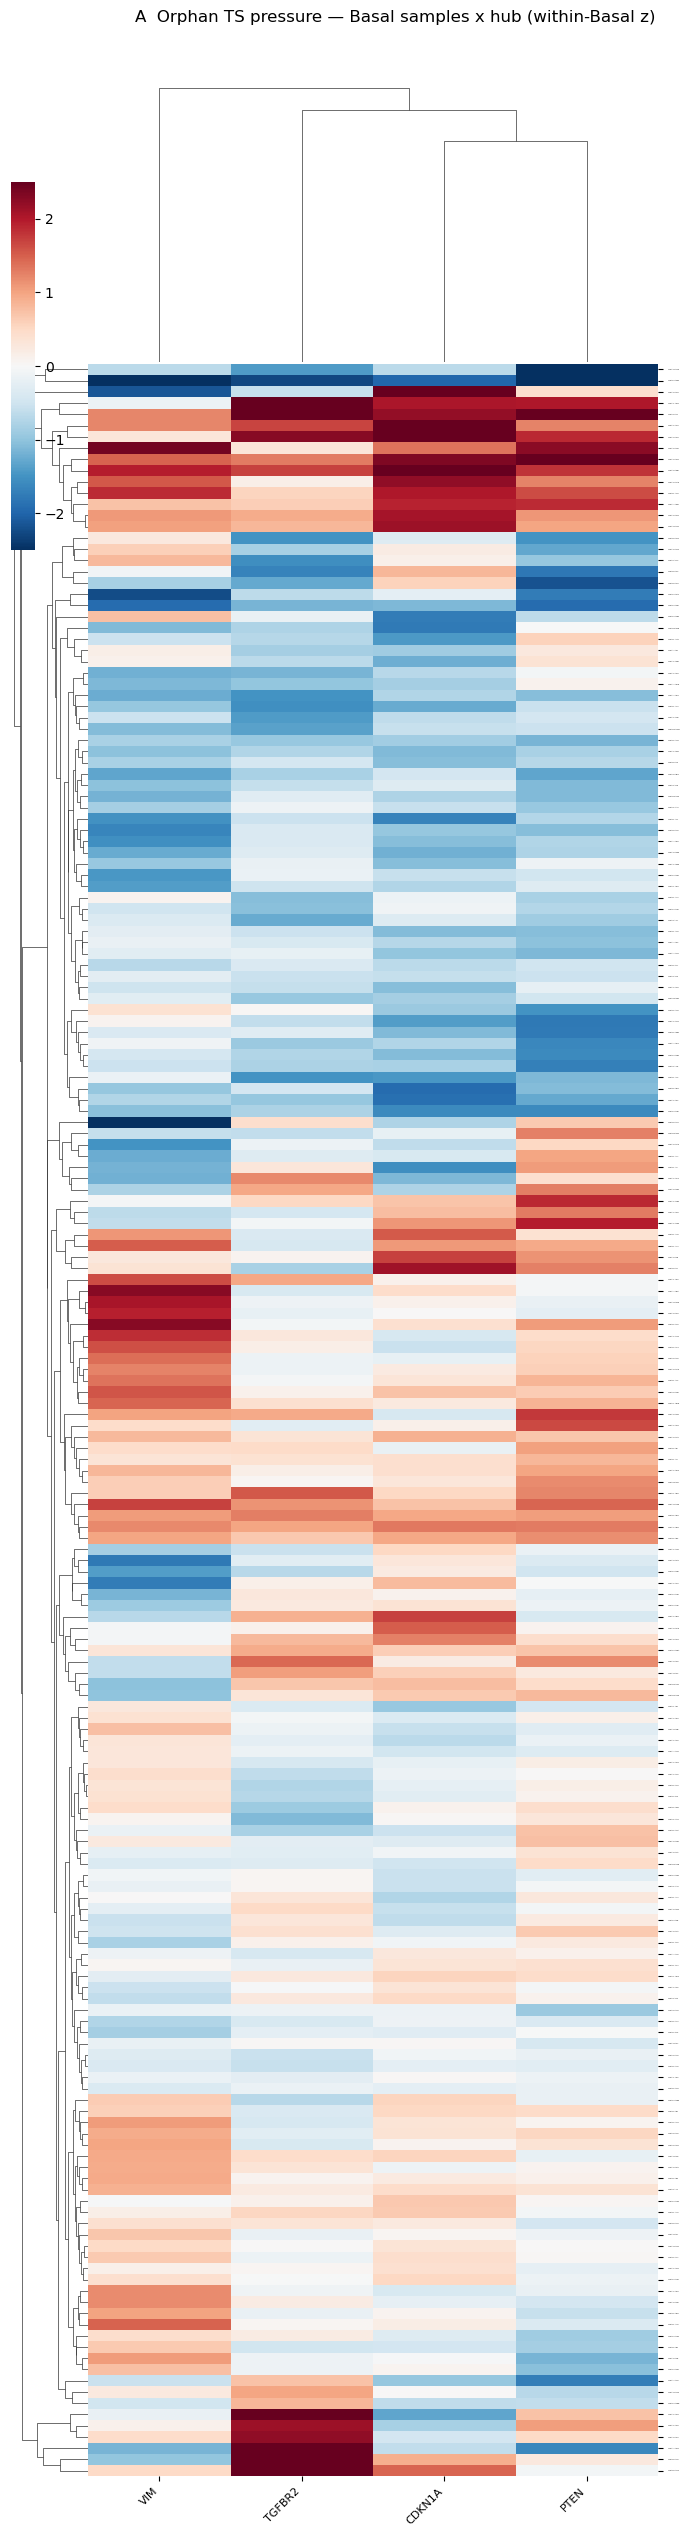

matrix: 188 Basal samples x 4 hub genes


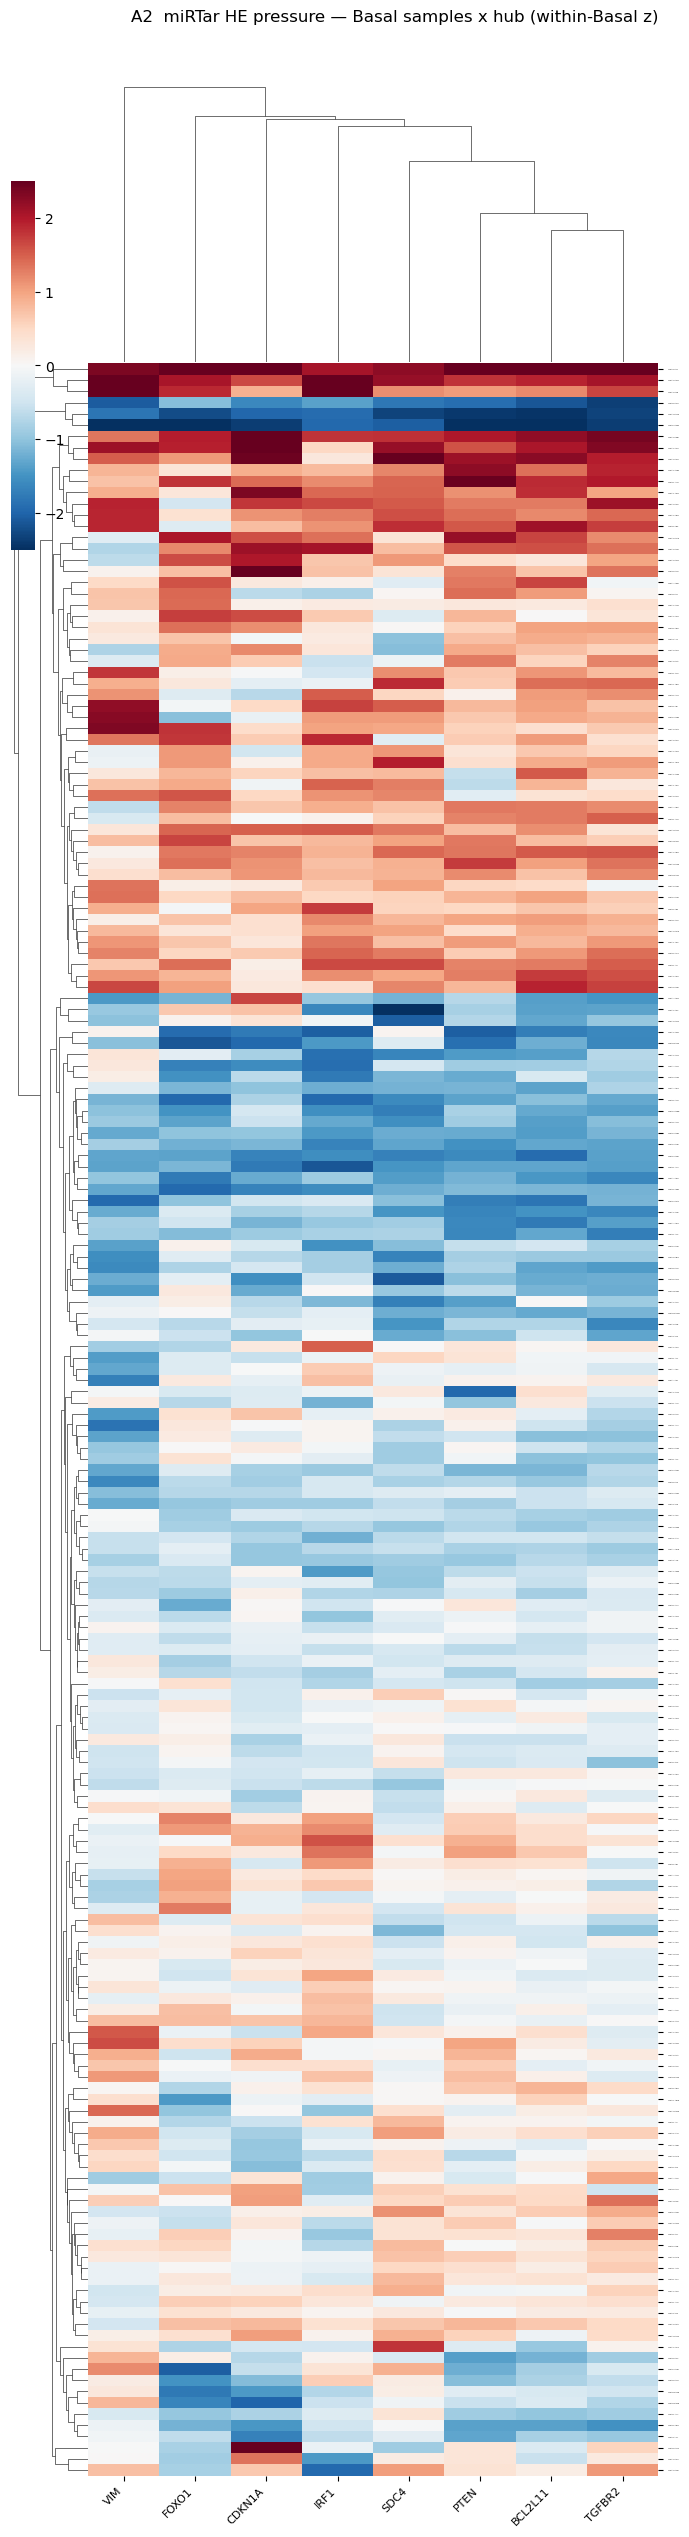

matrix: 188 Basal samples x 8 hub genes


In [13]:
# Heatmaps — orphan vs miRTar HE (hub routes) — edit SCOPE per cell
SCOPE = "Basal"
MIN_SURVIVES = 1   # orphan filter; miRTar panel uses all hub genes in pressure matrix

# A: samples x hub (orphan aggregate pressure)
sample_hub_pressure_heatmap(
    ORPHAN / "orphan_hub_gene_pressure_per_sample.tsv.gz",
    ORPHAN / "orphan_gene_aggregate_by_scope.tsv",
    scope=SCOPE,
    min_survives=MIN_SURVIVES,
    title="A  Orphan TS pressure",
)

# A2: samples x hub (miRTar HE aggregate pressure — all 8 hubs, no orphan survival filter)
mirtar_hub_p = AIM1 / "mirtar_hub_gene_pressure_per_sample.tsv.gz"
if mirtar_hub_p.exists():
    sample_hub_pressure_heatmap(
        mirtar_hub_p,
        aggregate_path=None,
        scope=SCOPE,
        title="A2  miRTar HE pressure",
    )
else:
    print(f"Missing {mirtar_hub_p} — regenerate via robustness_checks")



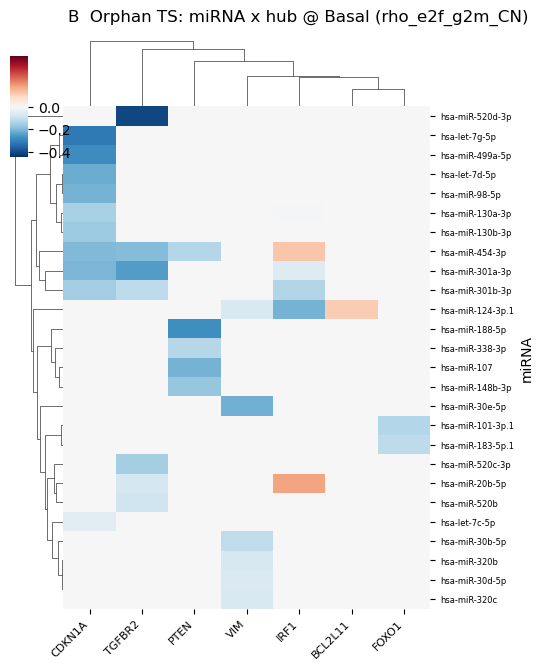

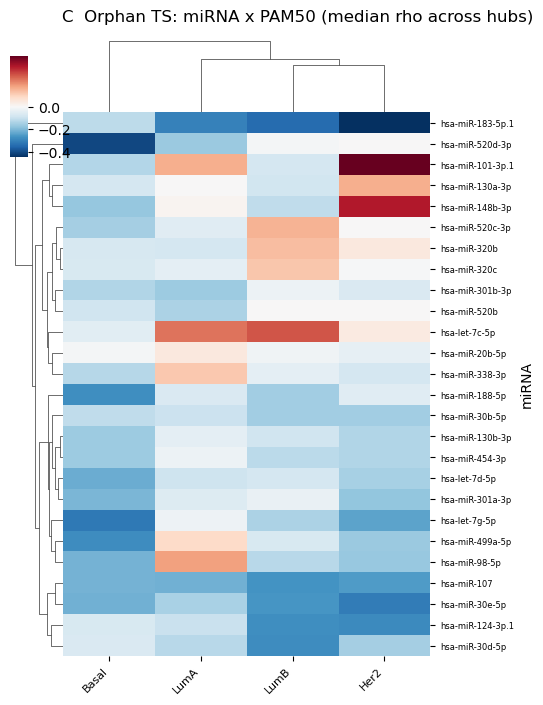

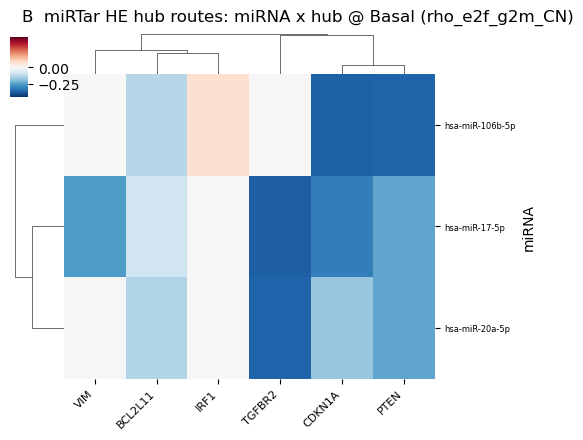

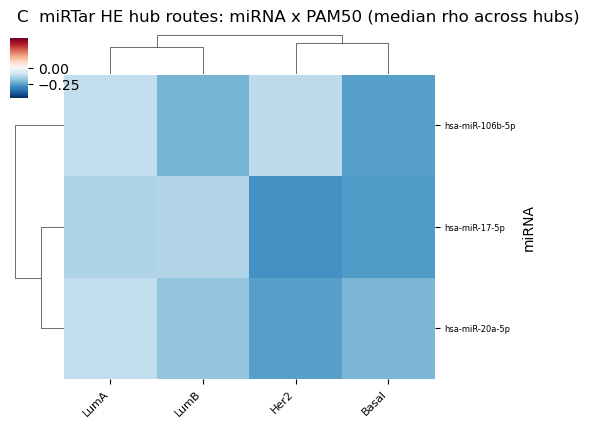

In [8]:
# B/C — miRNA x hub @ Basal; miRNA x PAM50 (orphan vs miRTar side-by-side)
RHO = "rho_e2f_g2m_CN"

for label, mat_path, sub_path in [
    ("Orphan TS", ORPHAN / "orphan_mirna_coupling_matrix_basal.tsv", ORPHAN / "orphan_mirna_coupling_by_subtype.tsv"),
    ("miRTar HE hub routes", AIM1 / "mirtar_mirna_coupling_matrix_basal.tsv", AIM1 / "mirtar_mirna_coupling_by_subtype.tsv"),
]:
    mat_bt = load_tsv(mat_path, index_col=0)
    mat_bt = mat_bt.loc[mat_bt.min(axis=1, skipna=True) < -0.05]
    mat_bt = mat_bt.dropna(axis=1, how="all")
    plot_coupling_clustermap(mat_bt, f"B  {label}: miRNA x hub @ Basal ({RHO})")

    mat_st = load_tsv(sub_path).set_index("miRNA").reindex(columns=list(PAM50_SUBTYPES))
    mat_st = mat_st.loc[mat_st.index.intersection(mat_bt.index)]
    plot_coupling_clustermap(mat_st, f"C  {label}: miRNA x PAM50 (median rho across hubs)")



### Top orphan miRNAs — why they matter (literature lens)

These arms are **TargetScan-strong but not miRTarBase HE**. They are *less canonical* in breast-cancer miRNA reviews than miR-21/155/17~92, which is exactly why they are interesting as **sequence-only** candidates:

| miRNA | Hub target(s) | miRTar studies | Literature note |
|-------|---------------|----------------|-----------------|
| **miR-301a/b** | CDKN1A, TGFBR2 | 0 (TS-only here) | Oncogenic **miR-301 family** reported in multiple cancers (incl. PTEN/p21 axis); less prominent in BRCA hub narratives than miR-17~92. |
| **miR-130b** | CDKN1A | 0 | **miR-130/301 cluster** (C19/MC-derived biology in some contexts); under-studied vs miR-17 route in TNBC bulk. |
| **miR-148b** | PTEN | 0 | **miR-148** linked to PTEN/methylation in several tumor types; not a default BRCA oncomiR. |
| **miR-520d** | TGFBR2 | 1 (not HE) | **C19MC miR-520** cluster — placenta-associated; sporadic cancer reports, rarely in BRCA immune-visibility framing. |
| **miR-499** | CDKN1A | 0 | **MyomiR** (muscle biology); off the usual breast oncomiR list — strong TS-only Basal coupling here is surprising. |
| **miR-454** | CDKN1A, TGFBR2 | 0 | Seed-related to **miR-301**; couples on shared hubs — supports *family clustering*, not noise. |
| **let-7g/d, miR-98** | CDKN1A | 1 (not HE for pair) | Famous **let-7** TS arms on p21 — coupling survives in Basal even when the specific pair is not HE-curated. |

**Takeaway:** the meaningful orphan signal is **not** random TS pairs — it concentrates on **under-reviewed seed families** hitting the same TSG nodes (p21/PTEN/TGFBR2) already implicated by the HE hub story.



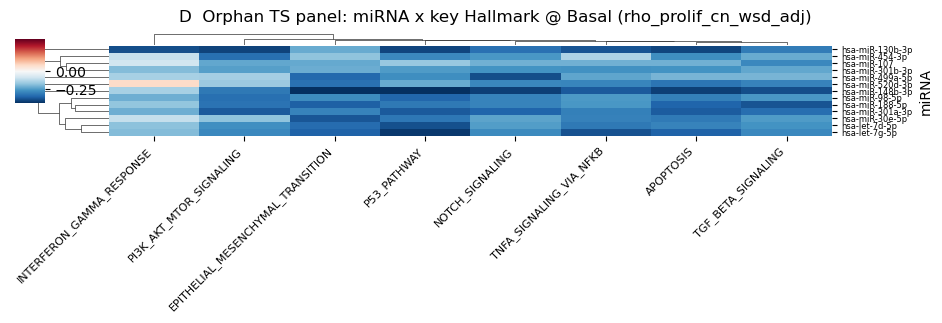

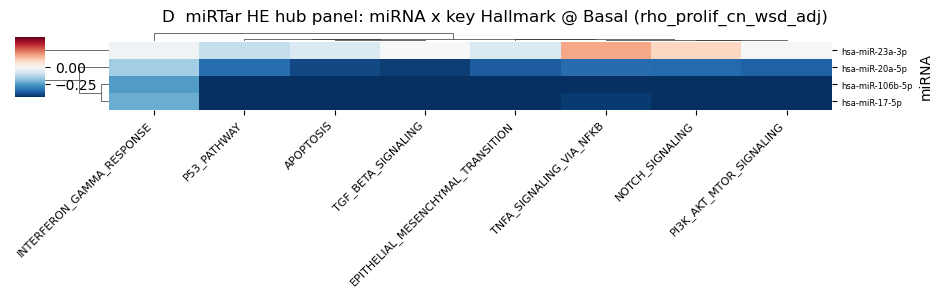

Top orphan miRNA x program (Basal neg-sig):


,miRNA,hallmark_set,rho_prolif_cn_wsd_adj,q_prolif_cn_wsd_adj,key_hallmark
247,hsa-miR-148b-3p,HALLMARK_UV_RESPONSE_UP,-0.5094,3.805636e-10,False
209,hsa-miR-148b-3p,HALLMARK_COAGULATION,-0.5090,3.805636e-10,False
213,hsa-miR-148b-3p,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,-0.4863,3.355324e-09,True
249,hsa-miR-148b-3p,HALLMARK_XENOBIOTIC_METABOLISM,-0.4790,5.585254e-09,False
203,hsa-miR-148b-3p,HALLMARK_ANGIOGENESIS,-0.4662,1.344694e-08,False
233,hsa-miR-148b-3p,HALLMARK_MYOGENESIS,-0.4650,1.344694e-08,False
204,hsa-miR-148b-3p,HALLMARK_APICAL_JUNCTION,-0.4647,1.344694e-08,False
236,hsa-miR-148b-3p,HALLMARK_P53_PATHWAY,-0.4639,1.344694e-08,True
221,hsa-miR-148b-3p,HALLMARK_HYPOXIA,-0.4497,4.907831e-08,False
598,hsa-miR-520d-3p,HALLMARK_WNT_BETA_CATENIN_SIGNALING,-0.4436,4.543113e-03,False


shape: (20, 5)


,miRNA,hallmark_set,rho_prolif_cn_wsd_adj,q_prolif_cn_wsd_adj,key_hallmark
247,hsa-miR-148b-3p,HALLMARK_UV_RESPONSE_UP,-0.5094,3.805636e-10,False
209,hsa-miR-148b-3p,HALLMARK_COAGULATION,-0.5090,3.805636e-10,False
213,hsa-miR-148b-3p,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,-0.4863,3.355324e-09,True
249,hsa-miR-148b-3p,HALLMARK_XENOBIOTIC_METABOLISM,-0.4790,5.585254e-09,False
203,hsa-miR-148b-3p,HALLMARK_ANGIOGENESIS,-0.4662,1.344694e-08,False
233,hsa-miR-148b-3p,HALLMARK_MYOGENESIS,-0.4650,1.344694e-08,False
204,hsa-miR-148b-3p,HALLMARK_APICAL_JUNCTION,-0.4647,1.344694e-08,False
236,hsa-miR-148b-3p,HALLMARK_P53_PATHWAY,-0.4639,1.344694e-08,True
221,hsa-miR-148b-3p,HALLMARK_HYPOXIA,-0.4497,4.907831e-08,False
598,hsa-miR-520d-3p,HALLMARK_WNT_BETA_CATENIN_SIGNALING,-0.4436,4.543113e-03,False


In [17]:
# D — miRNA x Hallmark program @ Basal (key programs only)
for label, path in [
    ("Orphan TS panel", ORPHAN / "orphan_mirna_hallmark_coupling_matrix_basal.tsv"),
    ("miRTar HE hub panel", ORPHAN / "mirtar_mirna_hallmark_coupling_matrix_basal.tsv"),
]:
    mat = load_tsv(path, index_col=0)
    mat = mat.loc[mat.min(axis=1, skipna=True) < -0.05]
    short = [h.replace("HALLMARK_", "") for h in mat.columns]
    mat.columns = short
    plot_coupling_clustermap(
        mat,
        f"D  {label}: miRNA x key Hallmark @ Basal (rho_prolif_cn_wsd_adj)",
        figsize=(10, max(4, 0.25 * len(mat) + 1)),
    )

# Long-form table: top orphan miRNA x program hits in Basal (neg-sig)
prog = load_tsv(ORPHAN / "orphan_mirna_hallmark_coupling_by_pam50.tsv")
basal = prog.loc[prog["subtype"] == "Basal"].copy()
basal["neg_sig"] = (basal["rho_prolif_cn_wsd_adj"] < 0) & (basal["q_prolif_cn_wsd_adj"] < 0.10)
print("Top orphan miRNA x program (Basal neg-sig):")
show(
    basal.loc[basal["neg_sig"]]
    .sort_values("rho_prolif_cn_wsd_adj")
    .head(20)[["miRNA", "hallmark_set", "rho_prolif_cn_wsd_adj", "q_prolif_cn_wsd_adj", "key_hallmark"]]
)



### Subtype overlap — which miRNAs / edges are shared?

**Membership rule:** hub (target, miRNA) edge with **ρ<0, p<0.05, survives CN+prolif** within that PAM50 subtype.

Panels **E1–F** compare orphan TS vs miRTar HE hub routes:
- **E1** UpSet-style bar: how many miRNAs are active in each subtype *pattern* (e.g. `Basal` only vs `LumA+LumB+Basal`).
- **E2** Jaccard matrix of miRNA sets between subtypes.
- **E3** Top hub edges × subtype (binary membership).
- **F** Clustered miRNA × subtype heatmap (any hub target).




Orphan TS hub edges — miRNA active in >=1 subtype (neg-sig + CN-survives on any hub):


,miRNA,seed_family,n_subtypes_active,subtypes_active,Basal_n_targets,LumA_n_targets,LumB_n_targets,Her2_n_targets
0,hsa-miR-301a-3p,miR-301,4,LumA+LumB+Her2+Basal,2,1,1,1
1,hsa-miR-107,miR-107,4,LumA+LumB+Her2+Basal,1,1,1,1
2,hsa-miR-30e-5p,other,4,LumA+LumB+Her2+Basal,1,1,1,1
3,hsa-miR-454-3p,miR-454,3,LumA+LumB+Basal,2,1,2,0
4,hsa-let-7g-5p,let-7,3,LumB+Her2+Basal,1,0,1,1
5,hsa-miR-183-5p.1,other,3,LumA+LumB+Her2,0,1,1,1
6,hsa-let-7d-5p,let-7,2,LumA+Basal,1,1,0,0
7,hsa-miR-188-5p,other,2,LumB+Basal,1,0,1,0
8,hsa-miR-301b-3p,miR-301,2,LumA+Basal,1,2,0,0
9,hsa-miR-17-5p,other,2,LumA+LumB,0,1,1,0


shape: (15, 8)


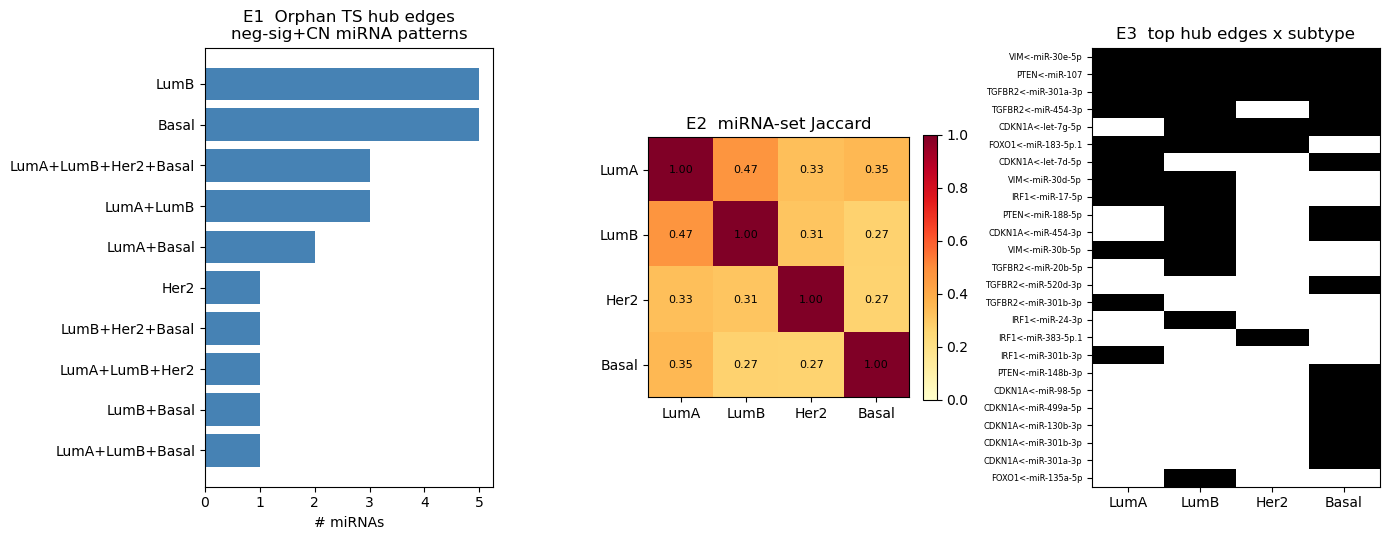

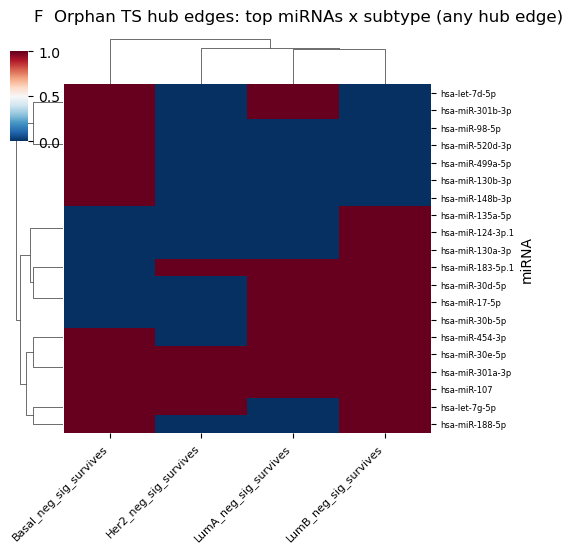


miRTar HE hub routes — miRNA active in >=1 subtype (neg-sig + CN-survives on any hub):


,miRNA,seed_family,n_subtypes_active,subtypes_active,Basal_n_targets,LumA_n_targets,LumB_n_targets,Her2_n_targets
0,hsa-miR-17-5p,other,4,LumA+LumB+Her2+Basal,4,4,4,4
1,hsa-miR-20a-5p,other,4,LumA+LumB+Her2+Basal,3,2,2,2
2,hsa-miR-106b-5p,other,4,LumA+LumB+Her2+Basal,2,2,3,1
3,hsa-miR-23a-3p,other,2,LumA+LumB,0,1,1,0


shape: (4, 8)


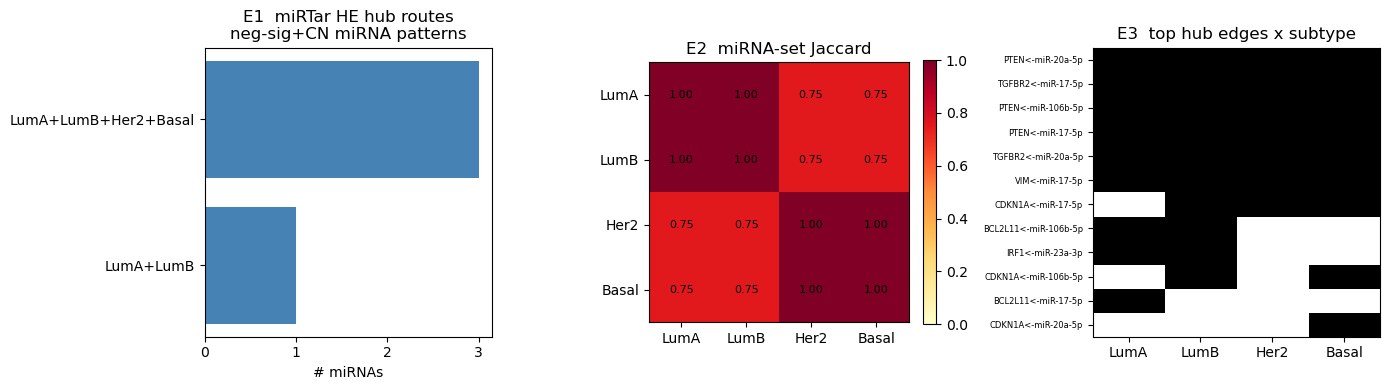

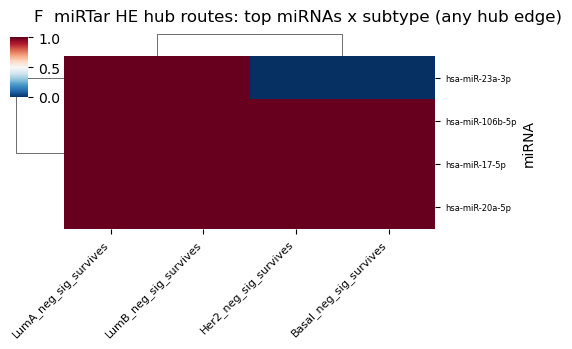

Orphan — Basal-only miRNAs (neg-sig+CN on any hub):


,miRNA,seed_family,edge_class,LumA_neg_sig_survives,LumA_n_targets,LumB_neg_sig_survives,LumB_n_targets,Her2_neg_sig_survives,Her2_n_targets,Basal_neg_sig_survives,Basal_n_targets,n_subtypes_active,subtypes_active,basal_only
12,hsa-miR-130b-3p,miR-130,orphan_ts,False,0,False,0,False,0,True,1,1,Basal,True
13,hsa-miR-148b-3p,miR-148,orphan_ts,False,0,False,0,False,0,True,1,1,Basal,True
14,hsa-miR-499a-5p,miR-499,orphan_ts,False,0,False,0,False,0,True,1,1,Basal,True
15,hsa-miR-520d-3p,miR-520,orphan_ts,False,0,False,0,False,0,True,1,1,Basal,True
16,hsa-miR-98-5p,let-7/98,orphan_ts,False,0,False,0,False,0,True,1,1,Basal,True


shape: (5, 14)
Orphan — active in all 4 subtypes:


,miRNA,seed_family,edge_class,LumA_neg_sig_survives,LumA_n_targets,LumB_neg_sig_survives,LumB_n_targets,Her2_neg_sig_survives,Her2_n_targets,Basal_neg_sig_survives,Basal_n_targets,n_subtypes_active,subtypes_active,basal_only
0,hsa-miR-301a-3p,miR-301,orphan_ts,True,1,True,1,True,1,True,2,4,LumA+LumB+Her2+Basal,False
1,hsa-miR-107,miR-107,orphan_ts,True,1,True,1,True,1,True,1,4,LumA+LumB+Her2+Basal,False
2,hsa-miR-30e-5p,other,orphan_ts,True,1,True,1,True,1,True,1,4,LumA+LumB+Her2+Basal,False


shape: (3, 14)


,miRNA,seed_family,edge_class,LumA_neg_sig_survives,LumA_n_targets,LumB_neg_sig_survives,LumB_n_targets,Her2_neg_sig_survives,Her2_n_targets,Basal_neg_sig_survives,Basal_n_targets,n_subtypes_active,subtypes_active,basal_only
0,hsa-miR-301a-3p,miR-301,orphan_ts,True,1,True,1,True,1,True,2,4,LumA+LumB+Her2+Basal,False
1,hsa-miR-107,miR-107,orphan_ts,True,1,True,1,True,1,True,1,4,LumA+LumB+Her2+Basal,False
2,hsa-miR-30e-5p,other,orphan_ts,True,1,True,1,True,1,True,1,4,LumA+LumB+Her2+Basal,False


In [18]:
# Subtype intersection — orphan vs miRTar (neg-sig + CN-surviving hub edges)
plot_subtype_overlap_panels(ORPHAN, "orphan", label="Orphan TS hub edges")
plot_subtype_overlap_panels(ORPHAN, "mirtar", label="miRTar HE hub routes")

# Side-by-side: miRNAs active in Basal only vs shared (orphan)
mir_o = load_tsv(ORPHAN / "orphan_mirna_subtype_membership.tsv")
print("Orphan — Basal-only miRNAs (neg-sig+CN on any hub):")
show(mir_o.loc[mir_o["basal_only"]].sort_values("Basal_n_targets", ascending=False))
print("Orphan — active in all 4 subtypes:")
show(mir_o.loc[mir_o["n_subtypes_active"] == 4])

